Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using file: /content/drive/MyDrive/spotify/spotify-2023.csv

Columns found:
['track_name', 'artist_s__name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']

Prepared dataset shape: (952, 16)
Top artists: 238 songs from top-tier artists

Descriptive statistics:
            streams  in_spotify_playlists  in_apple_playlists  \
count  9.520000e+02            952.000000          952.000000   
mean   5.141374e+08           5202.565126           67.866597   
std    5.668569e+08           7901.400683           86.470591   
min    2.762000e+03             31.000000       

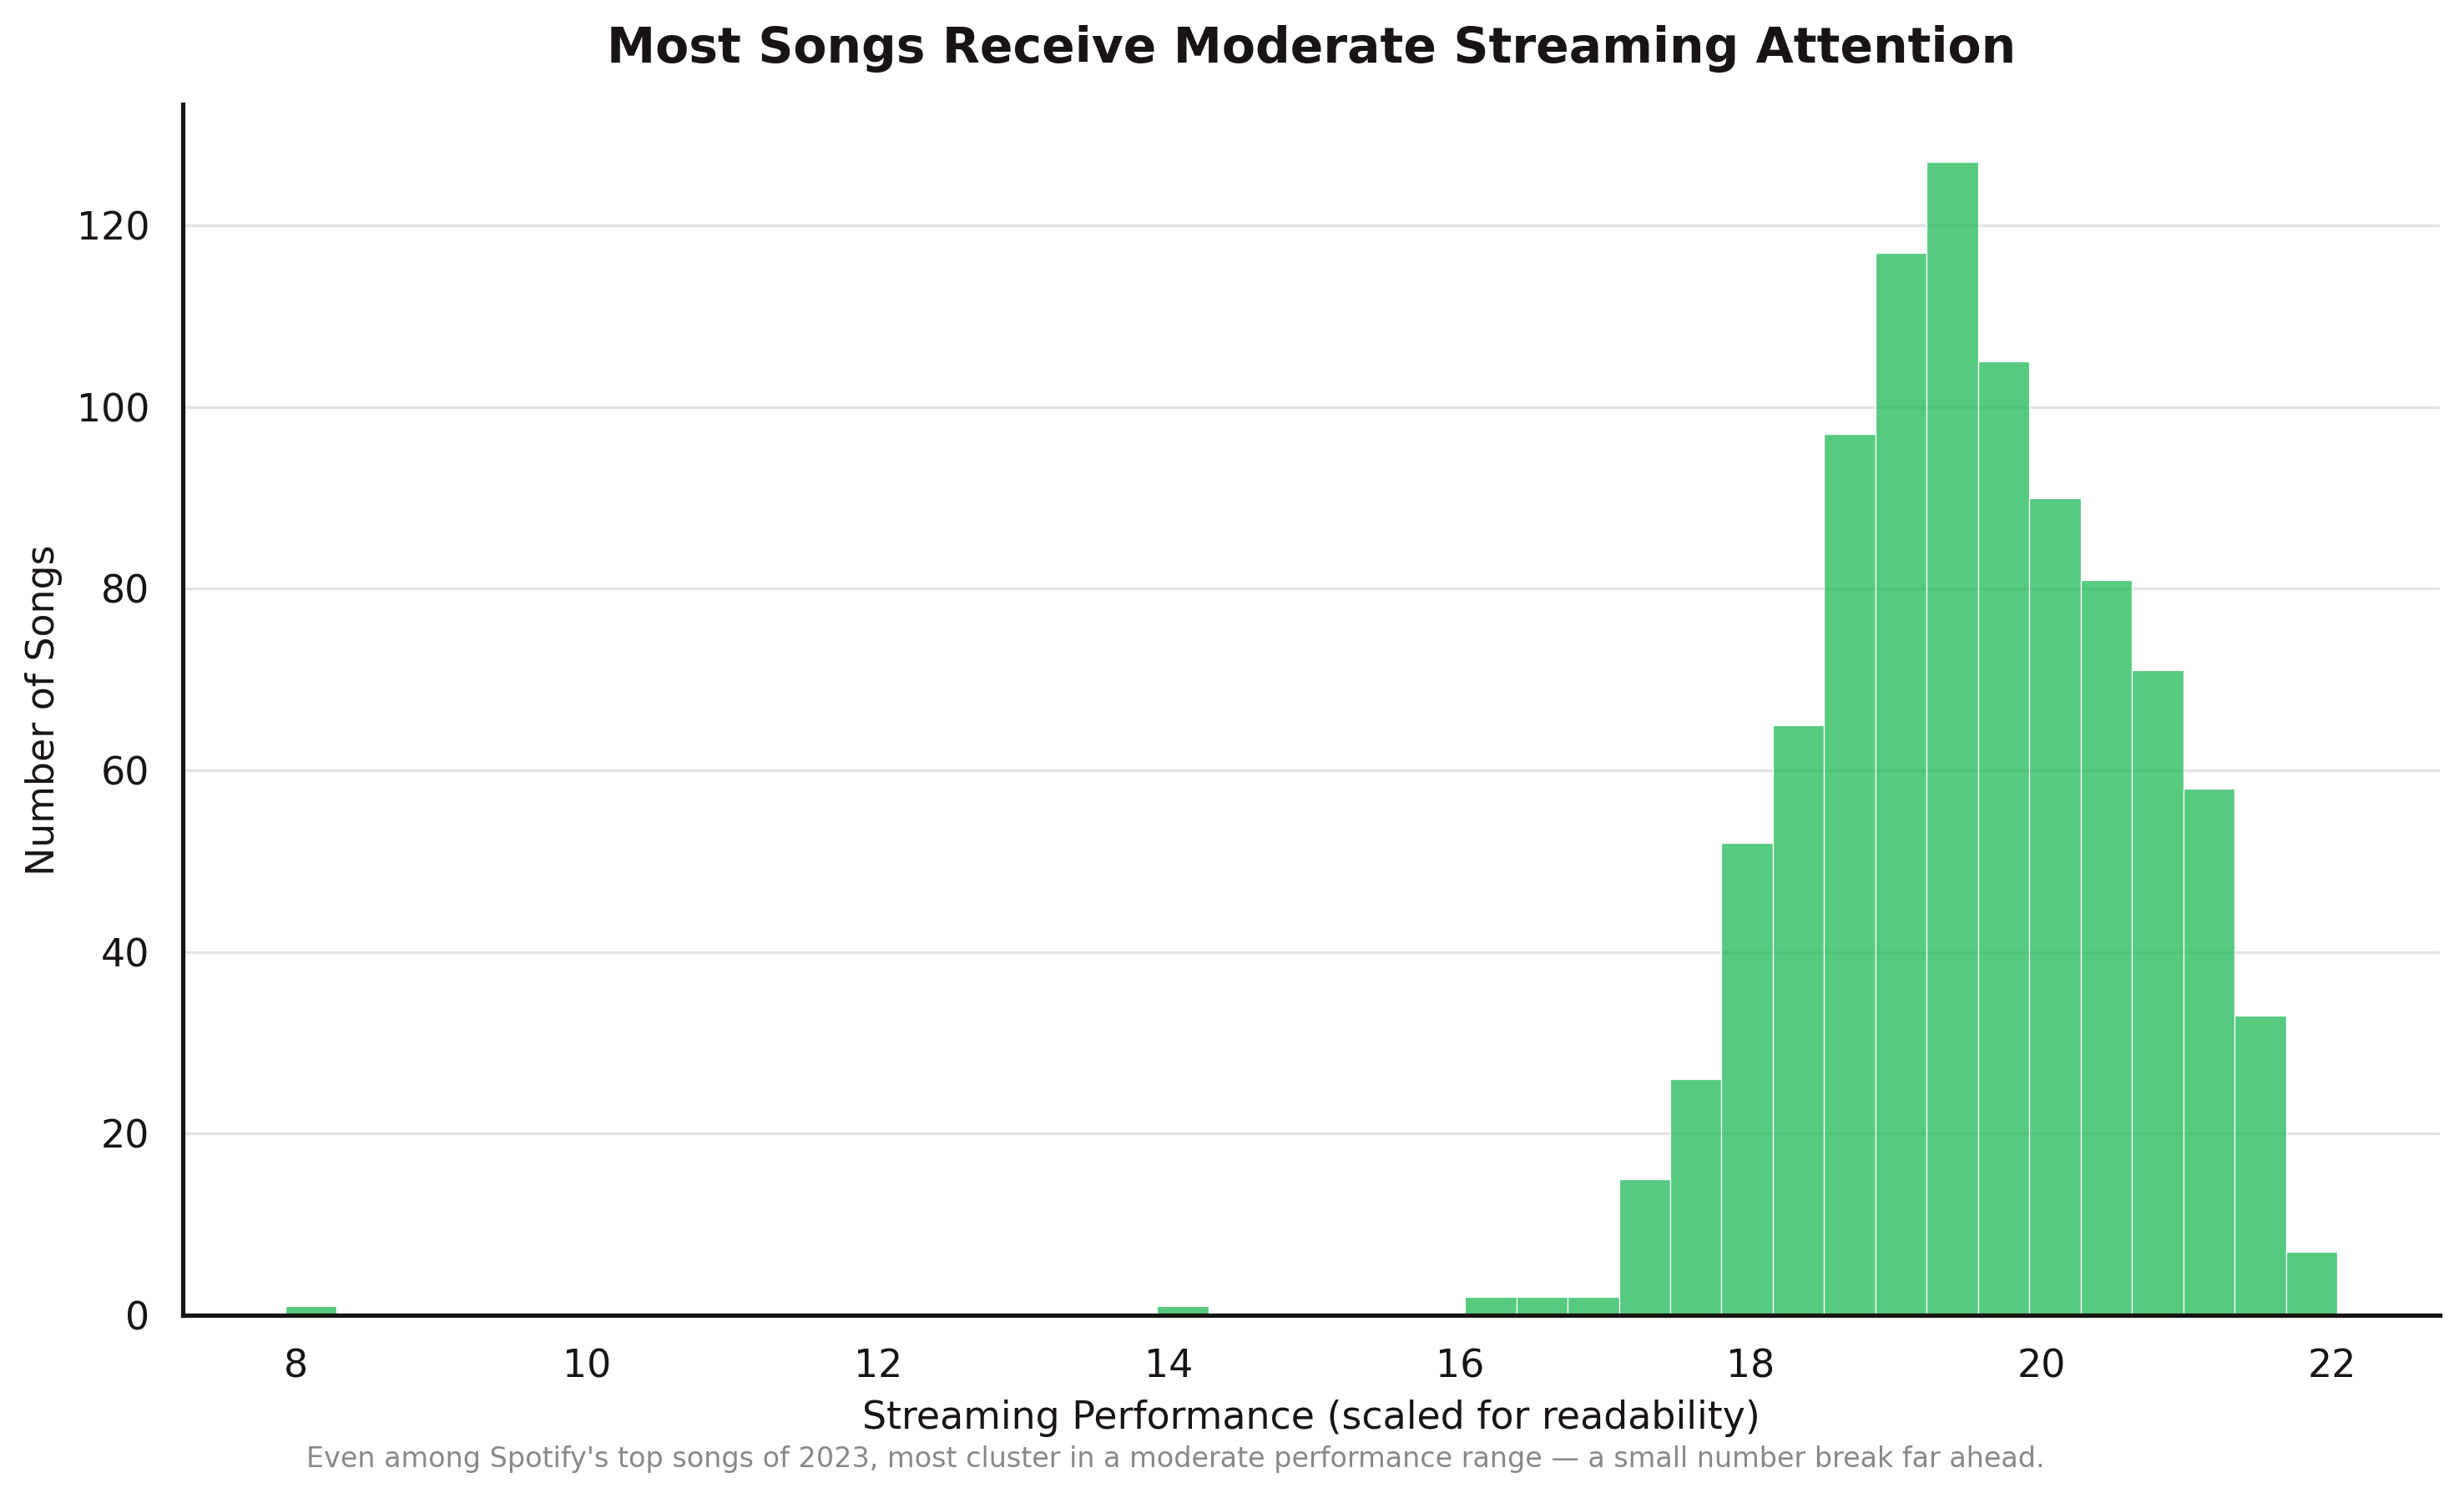

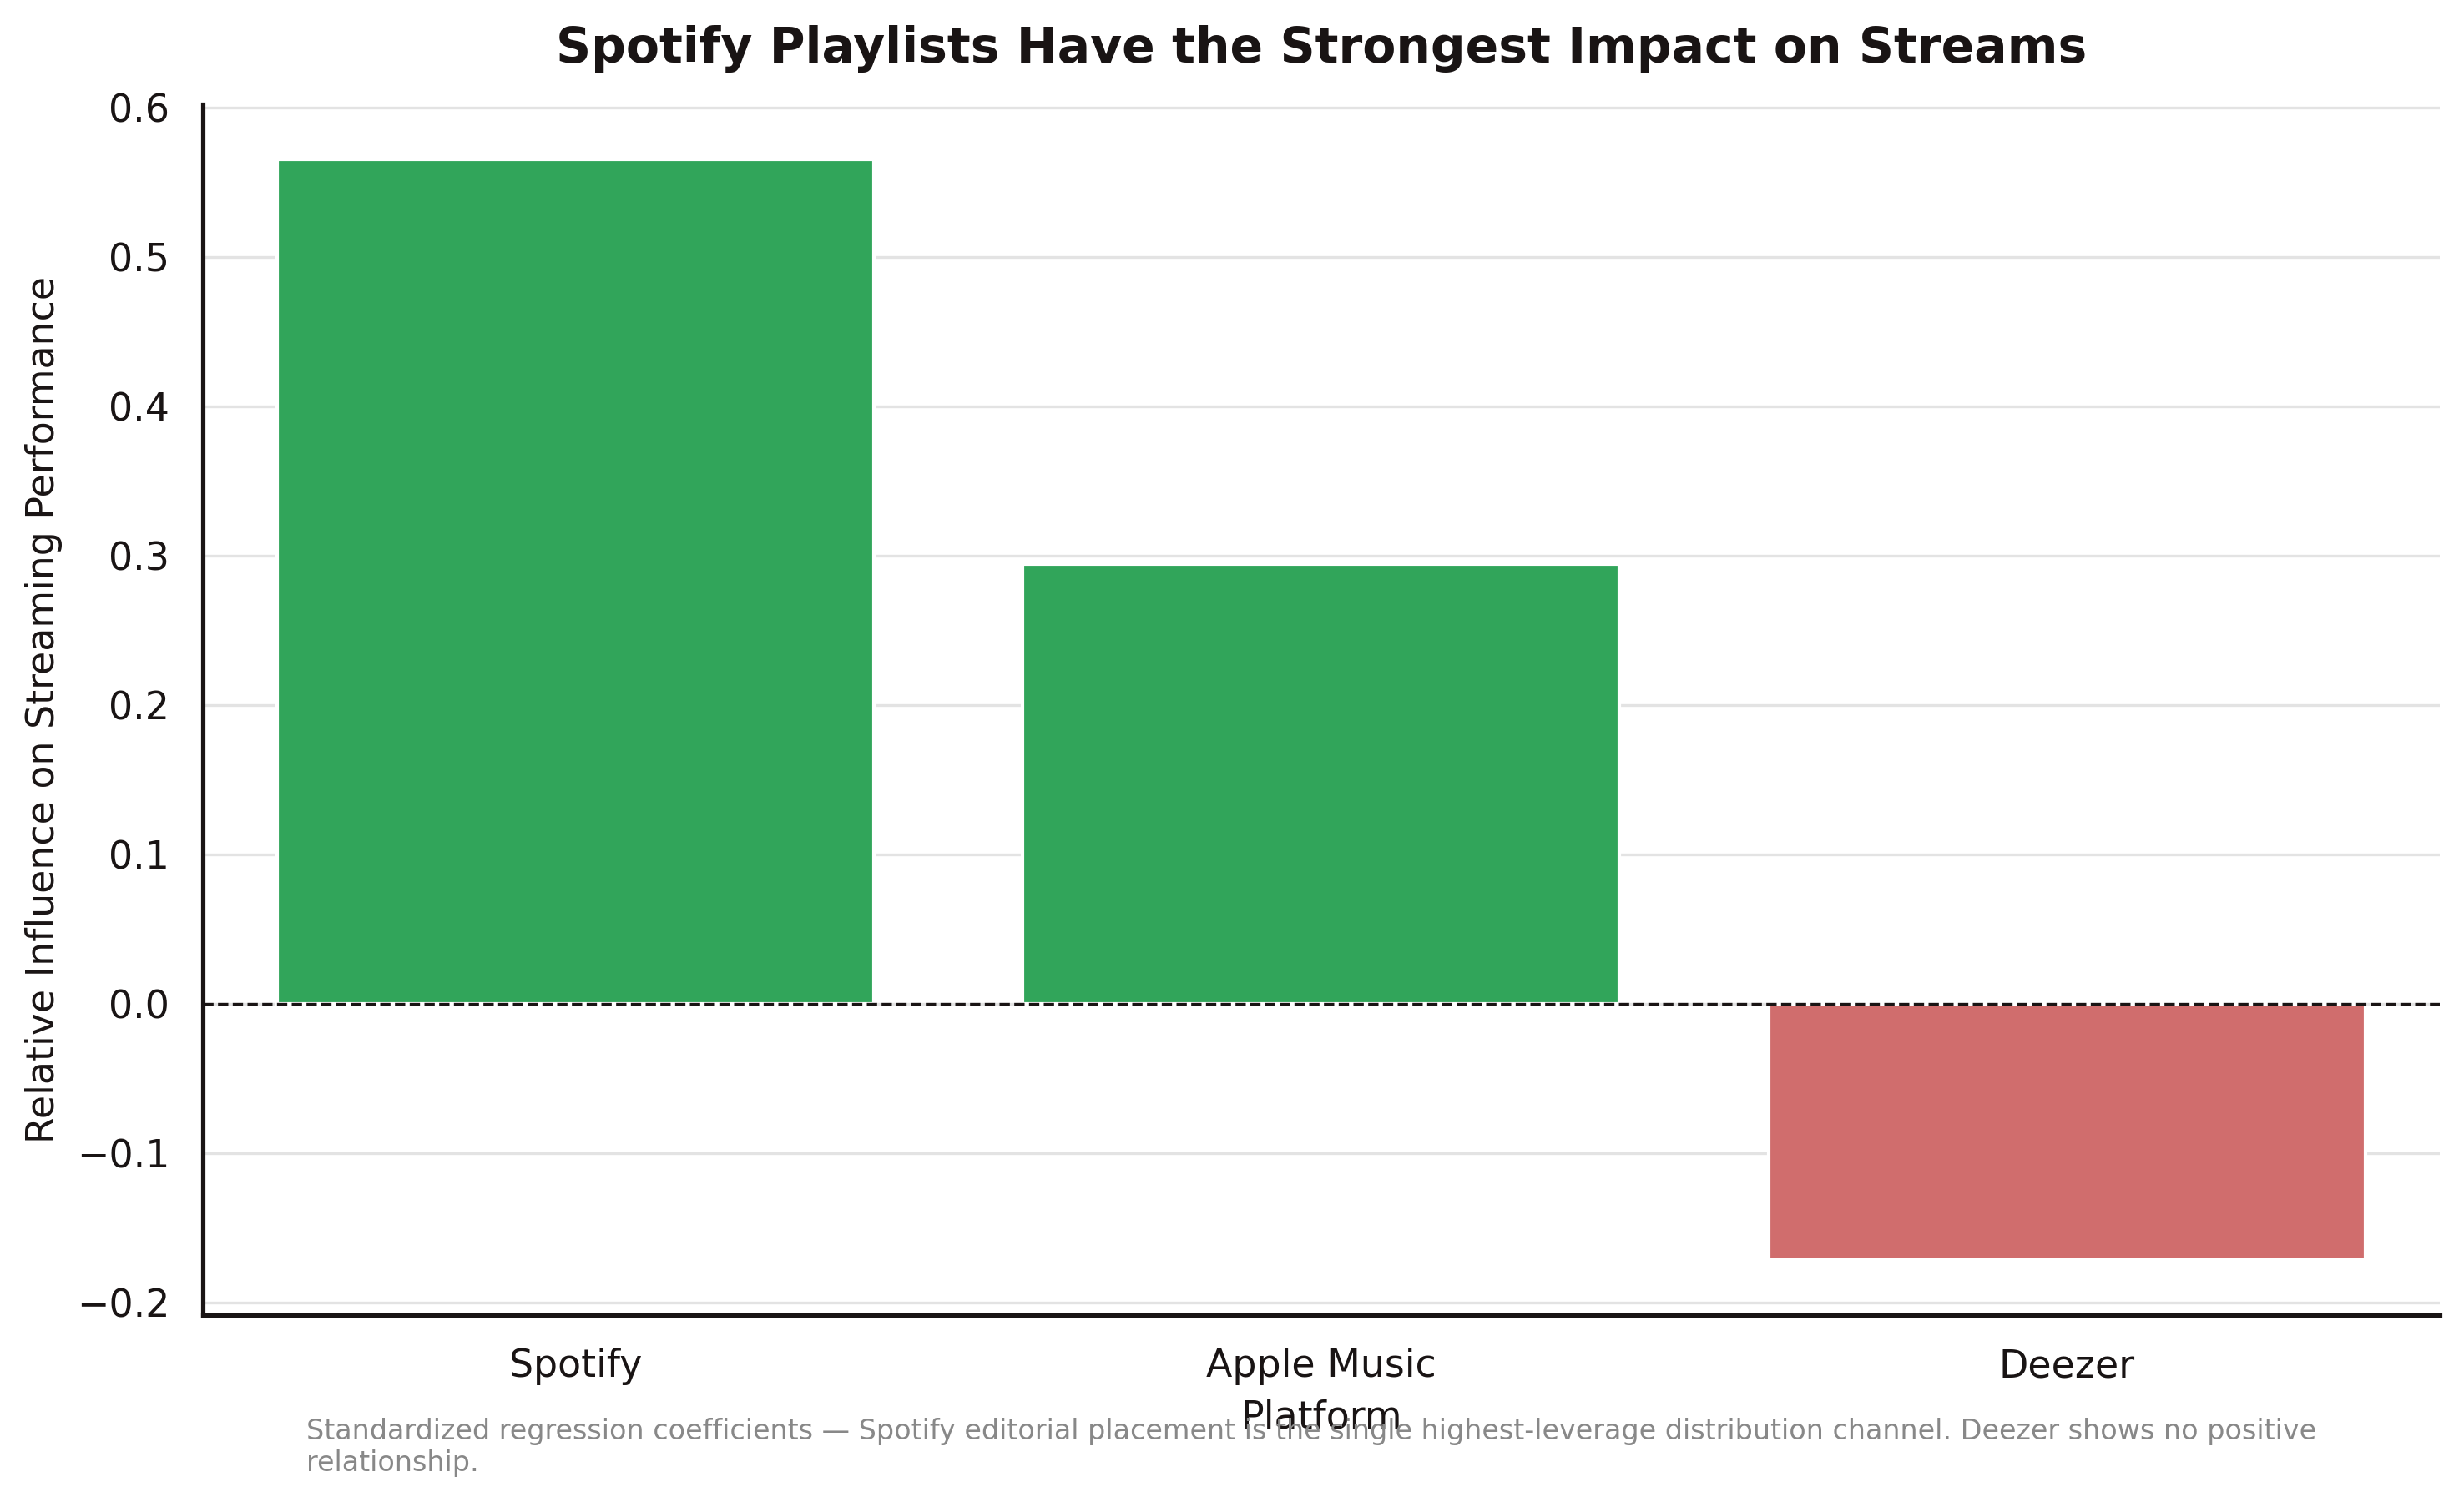

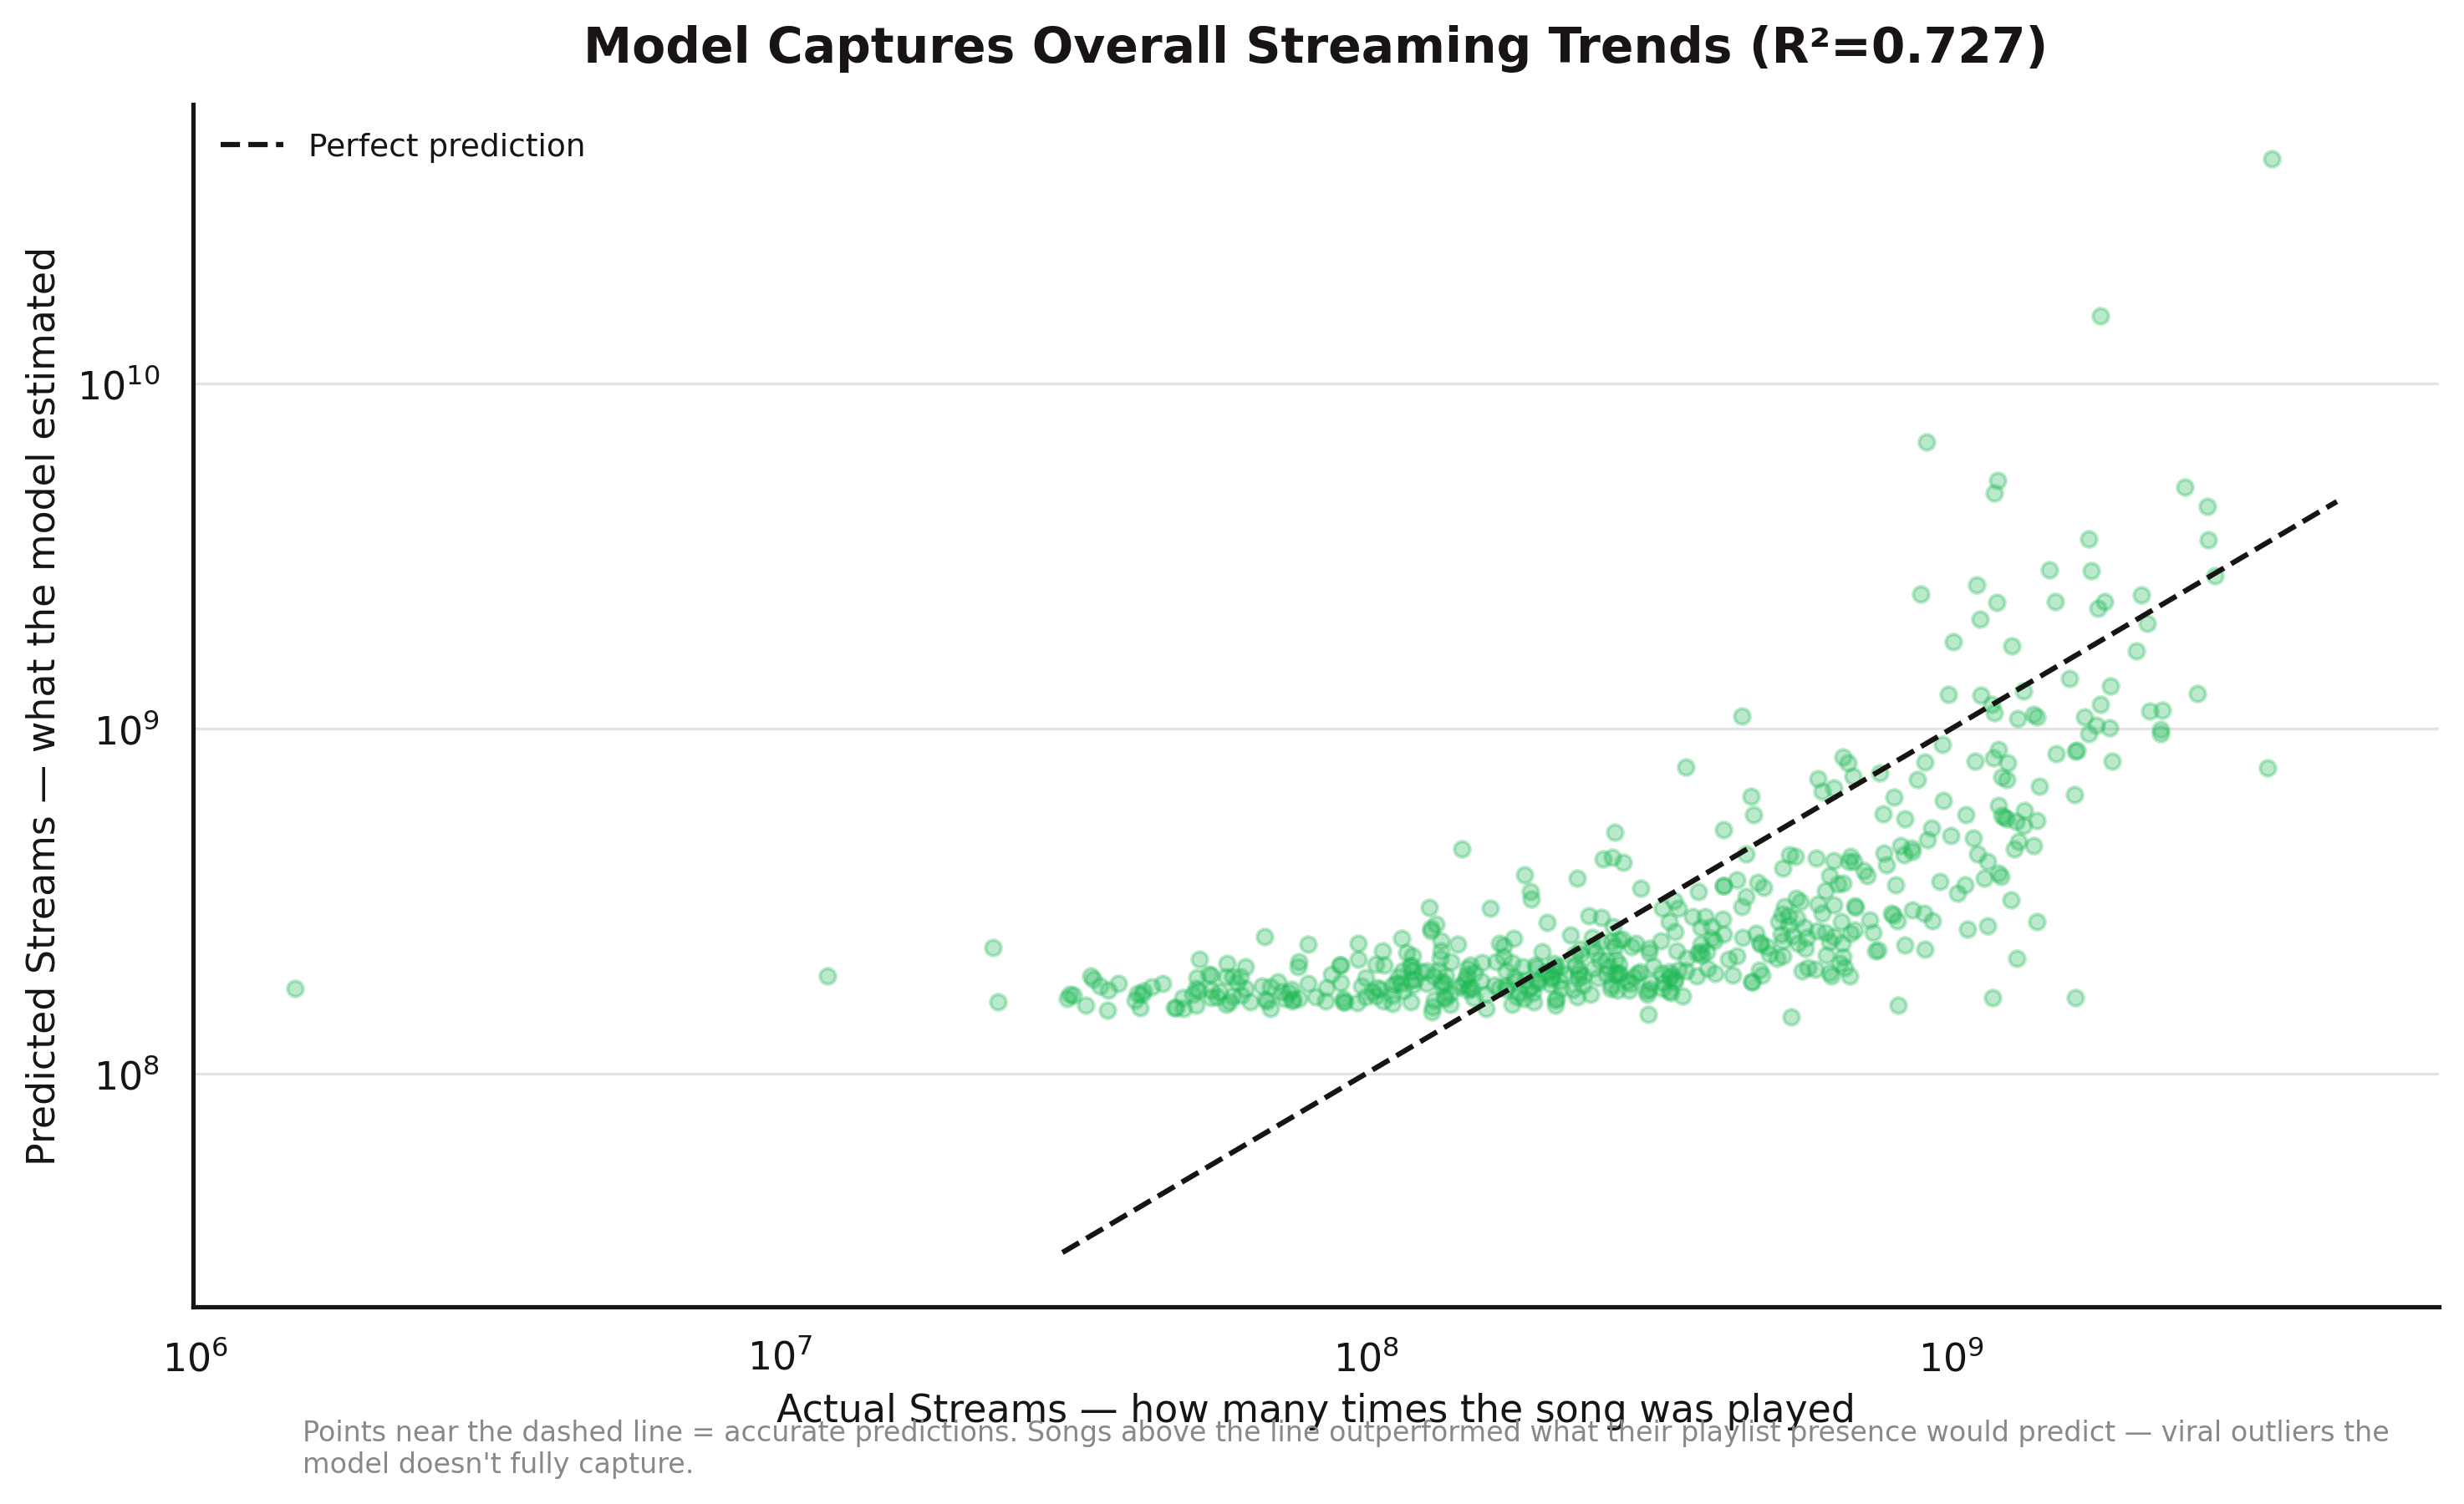

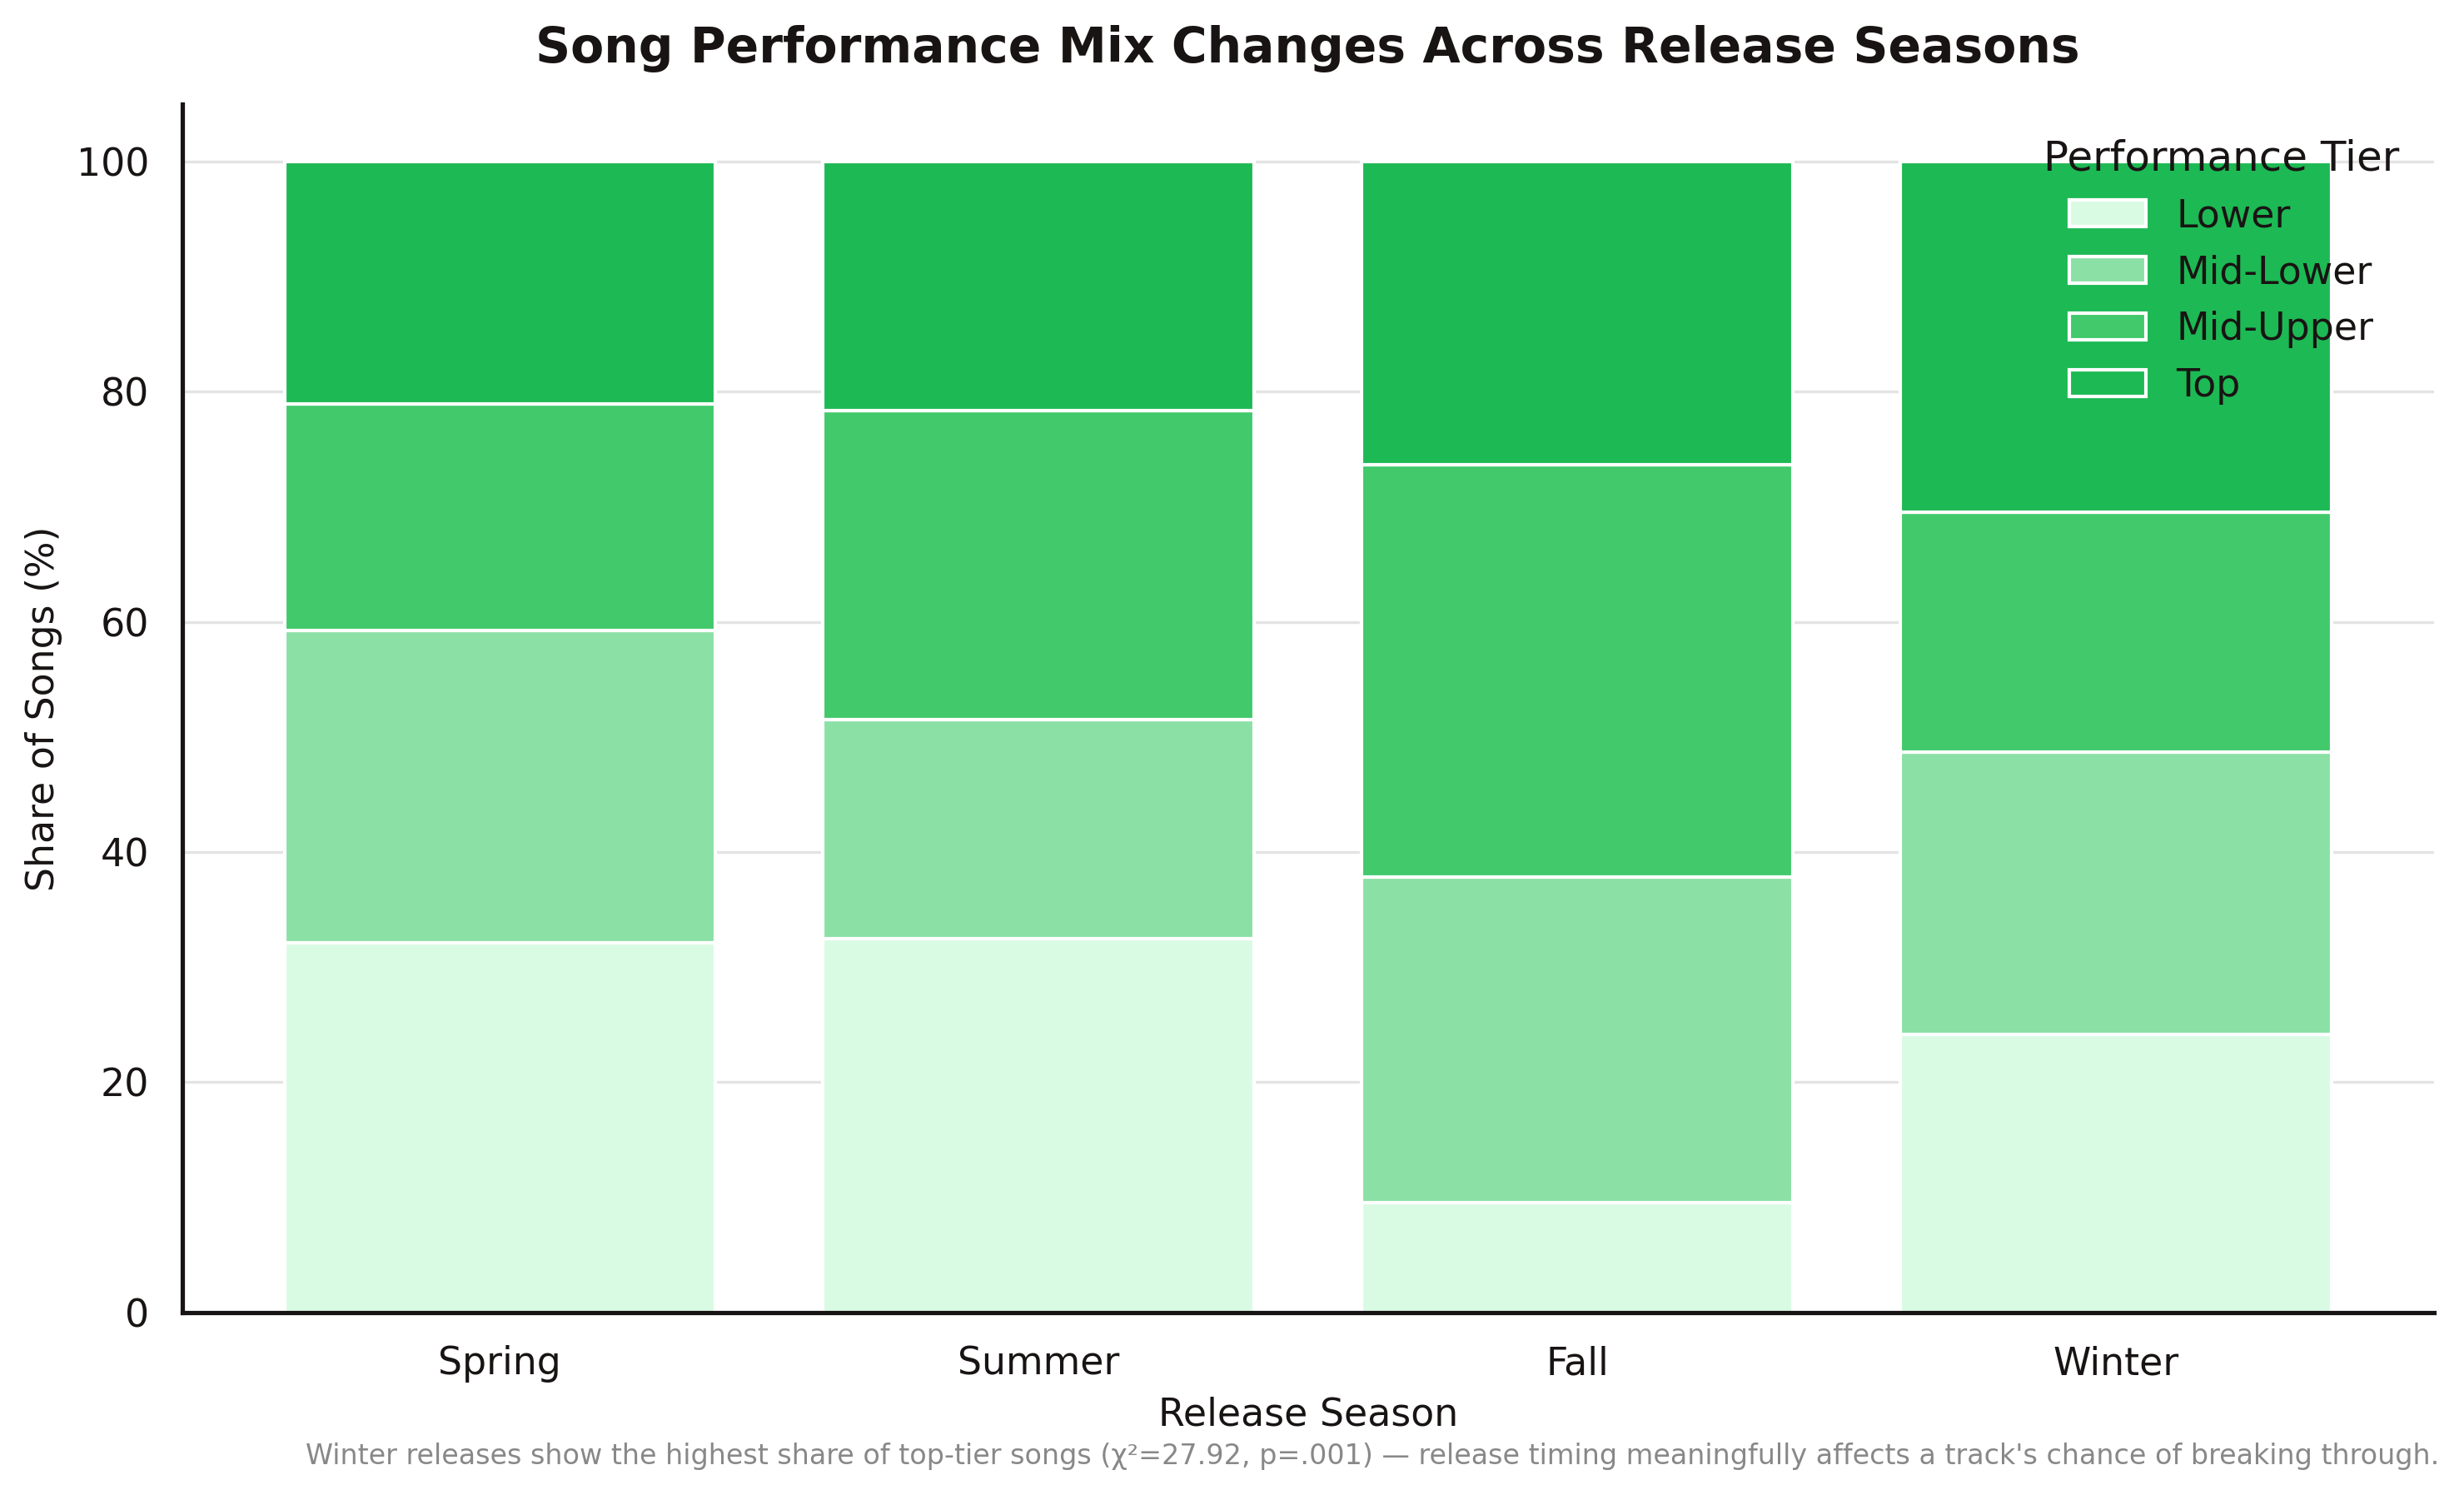

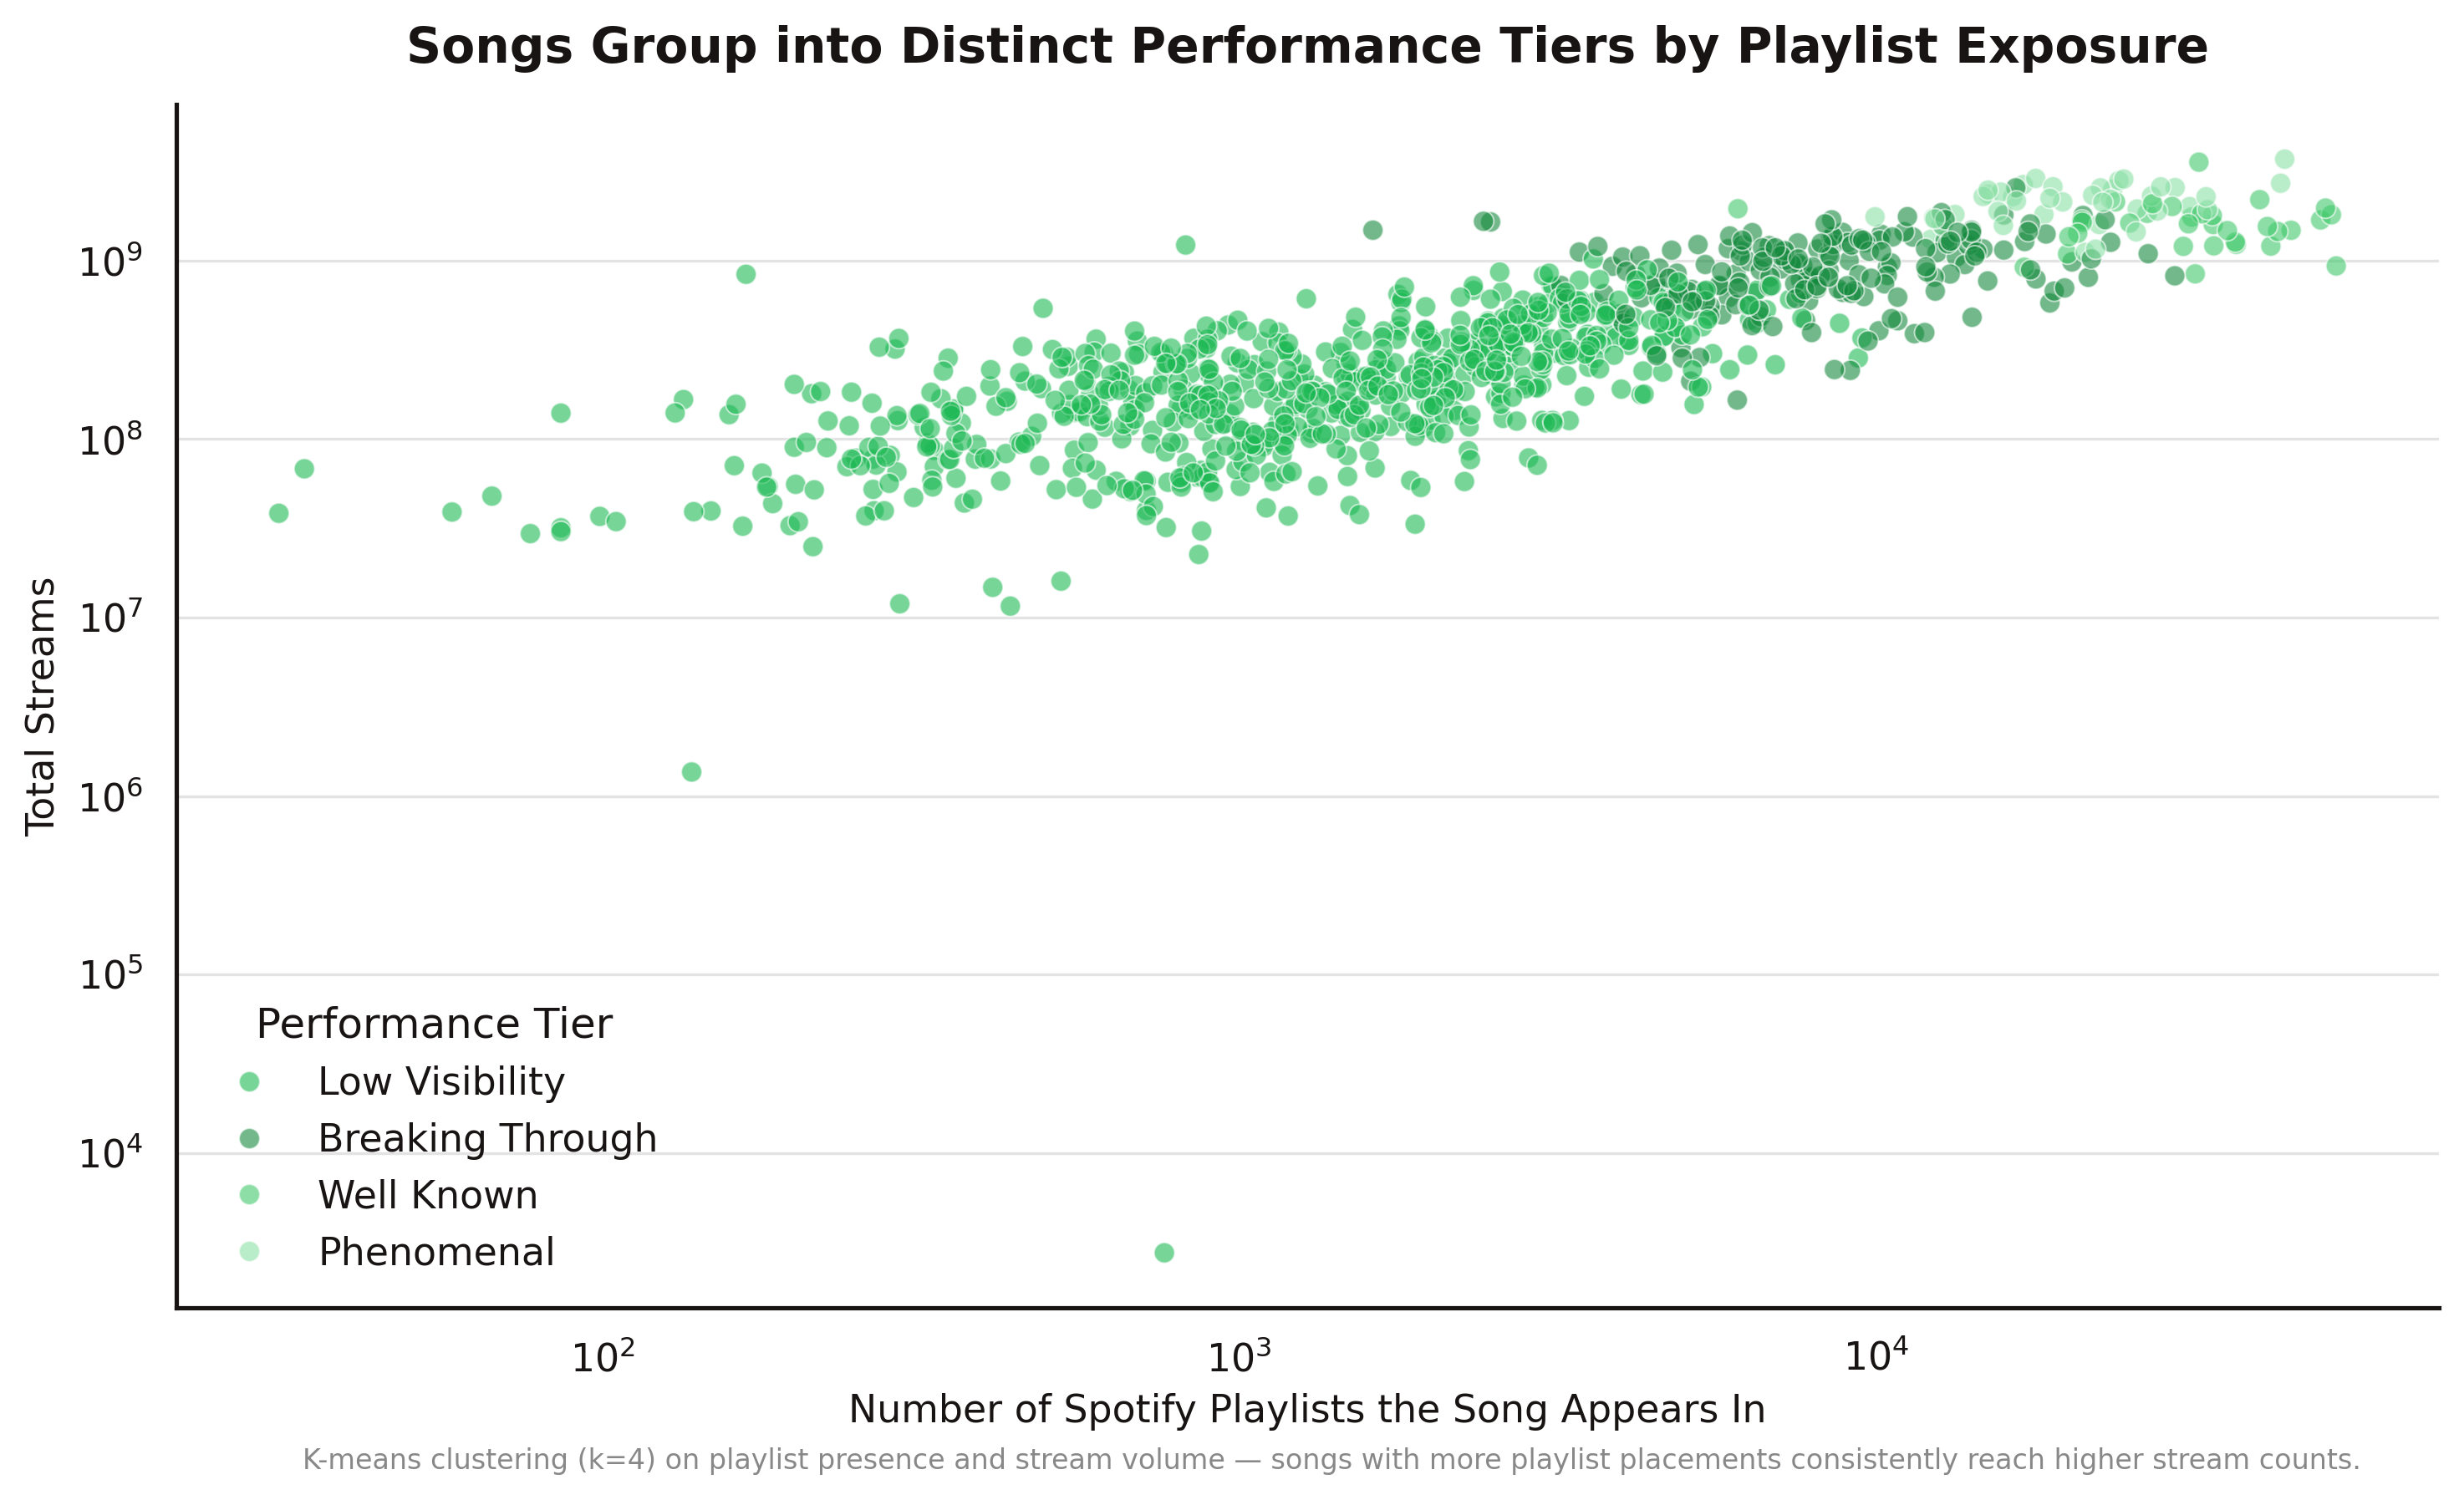

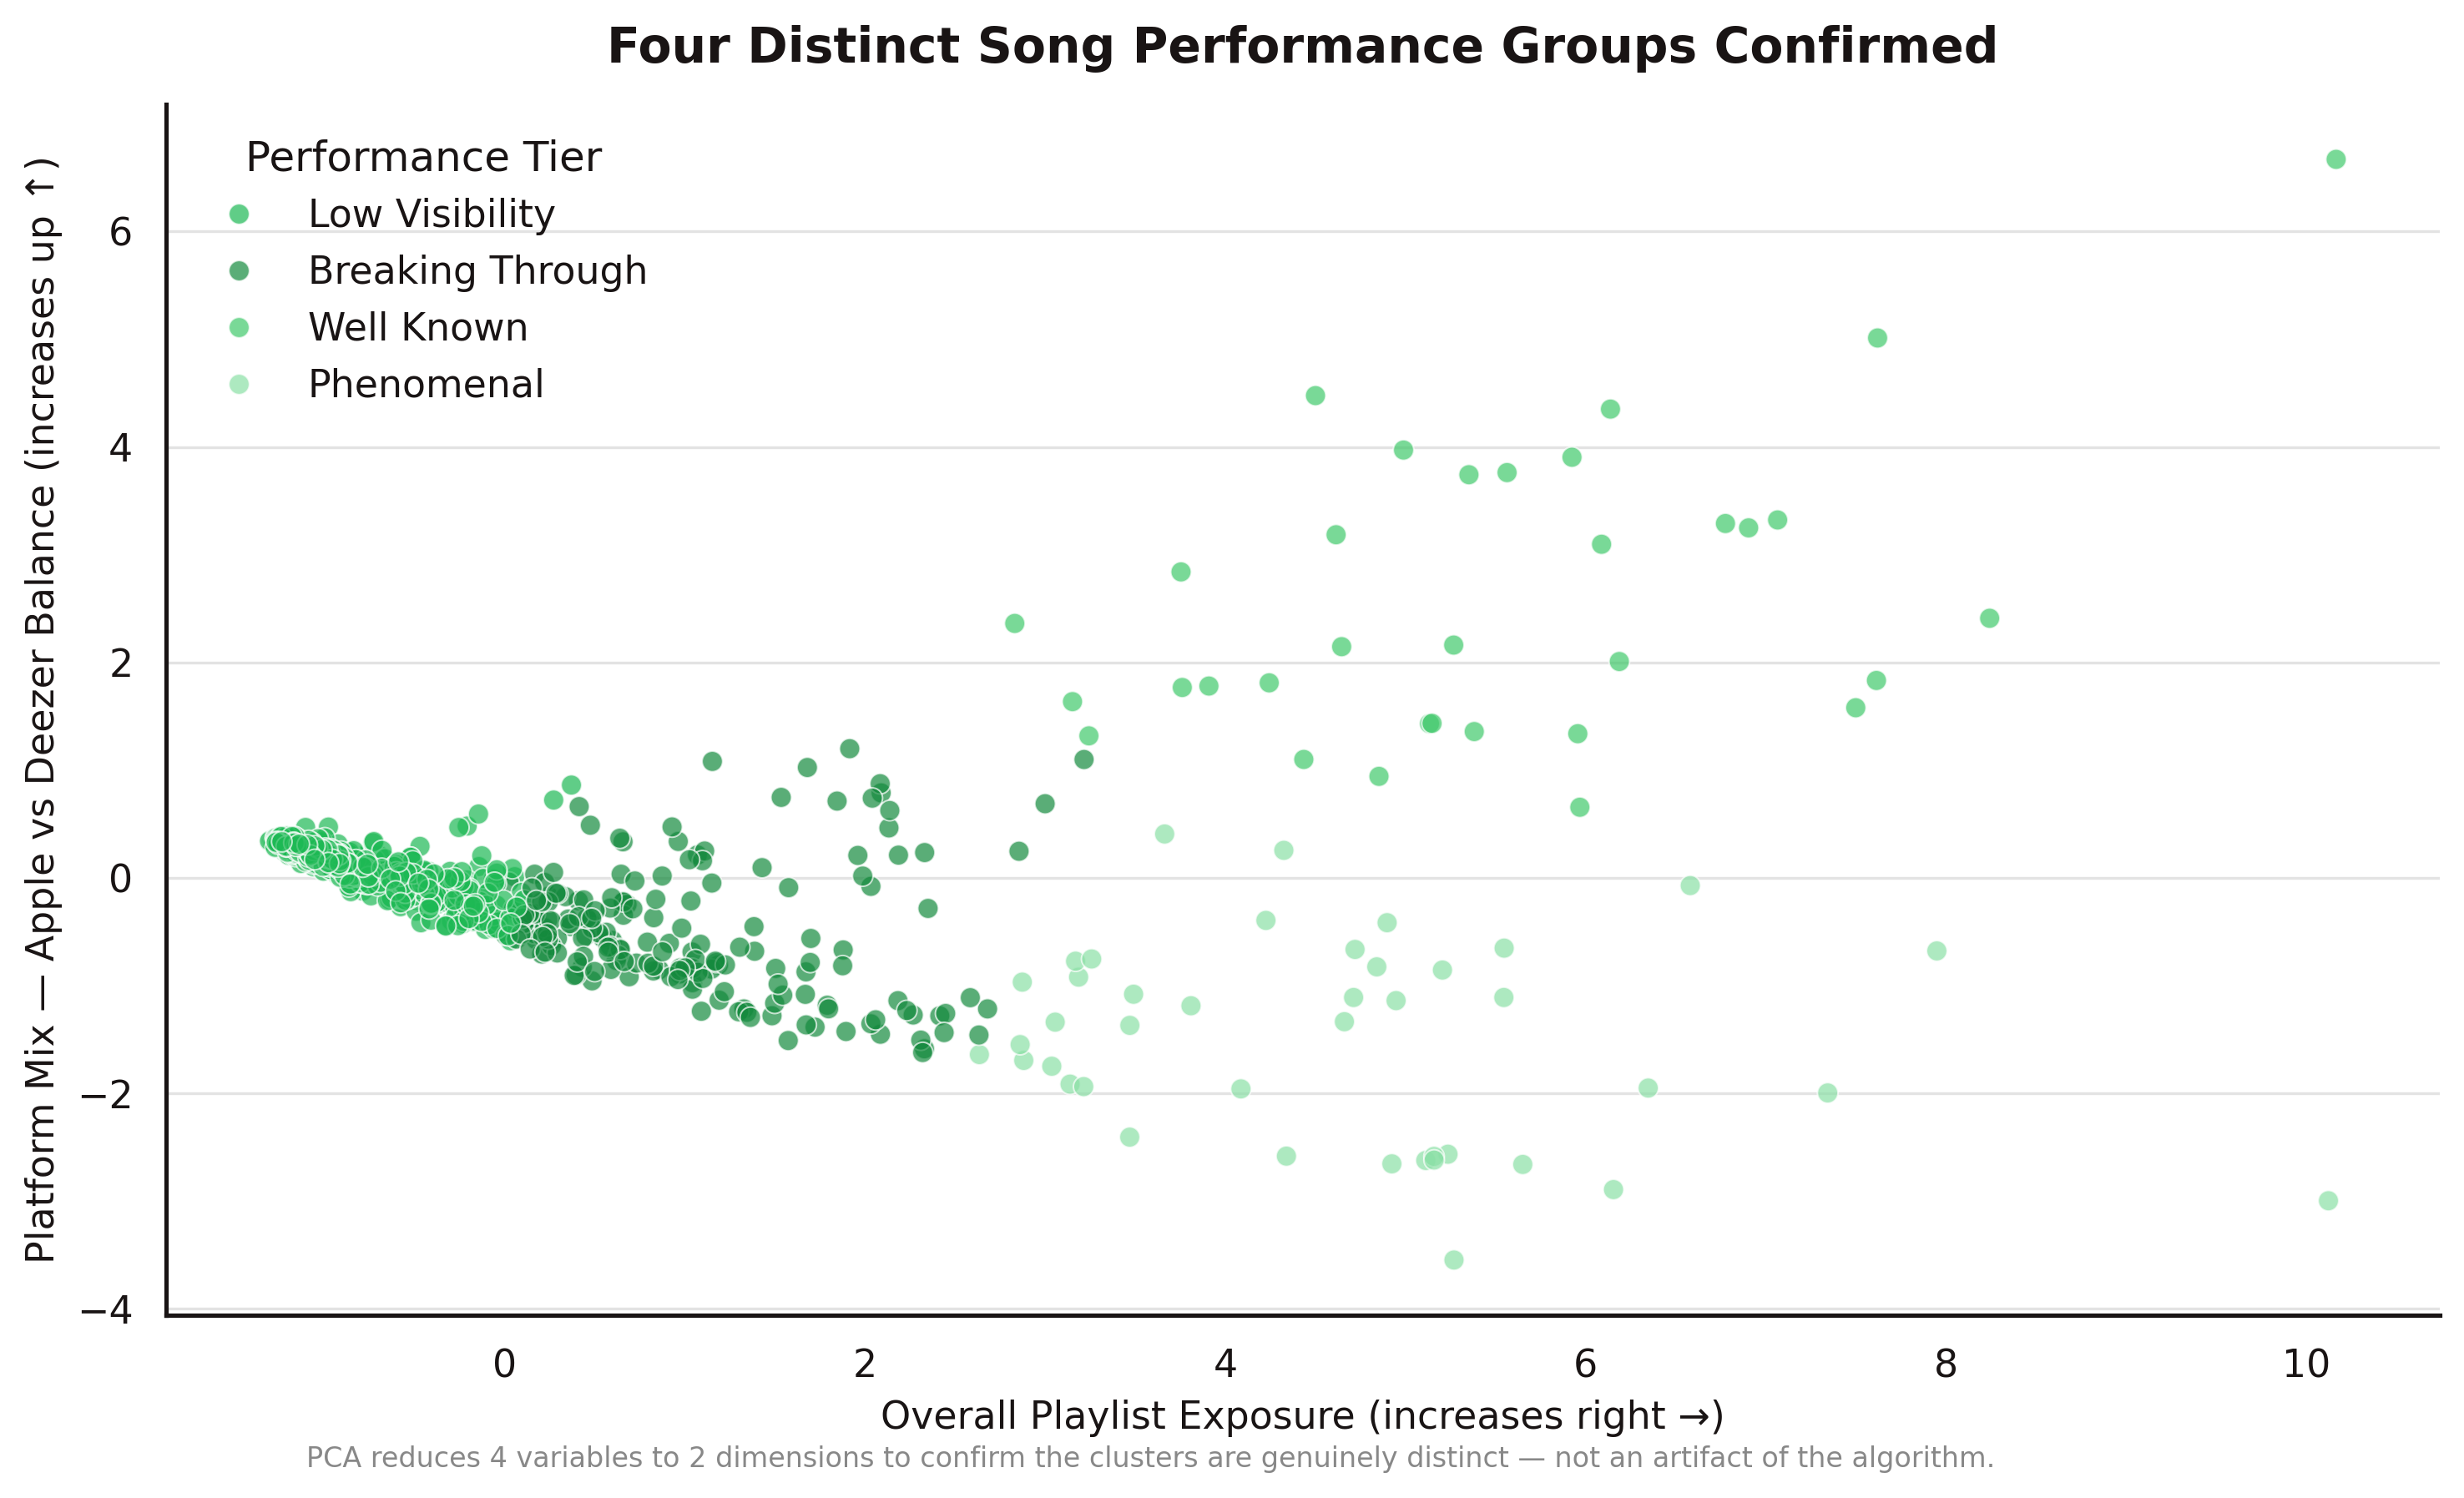

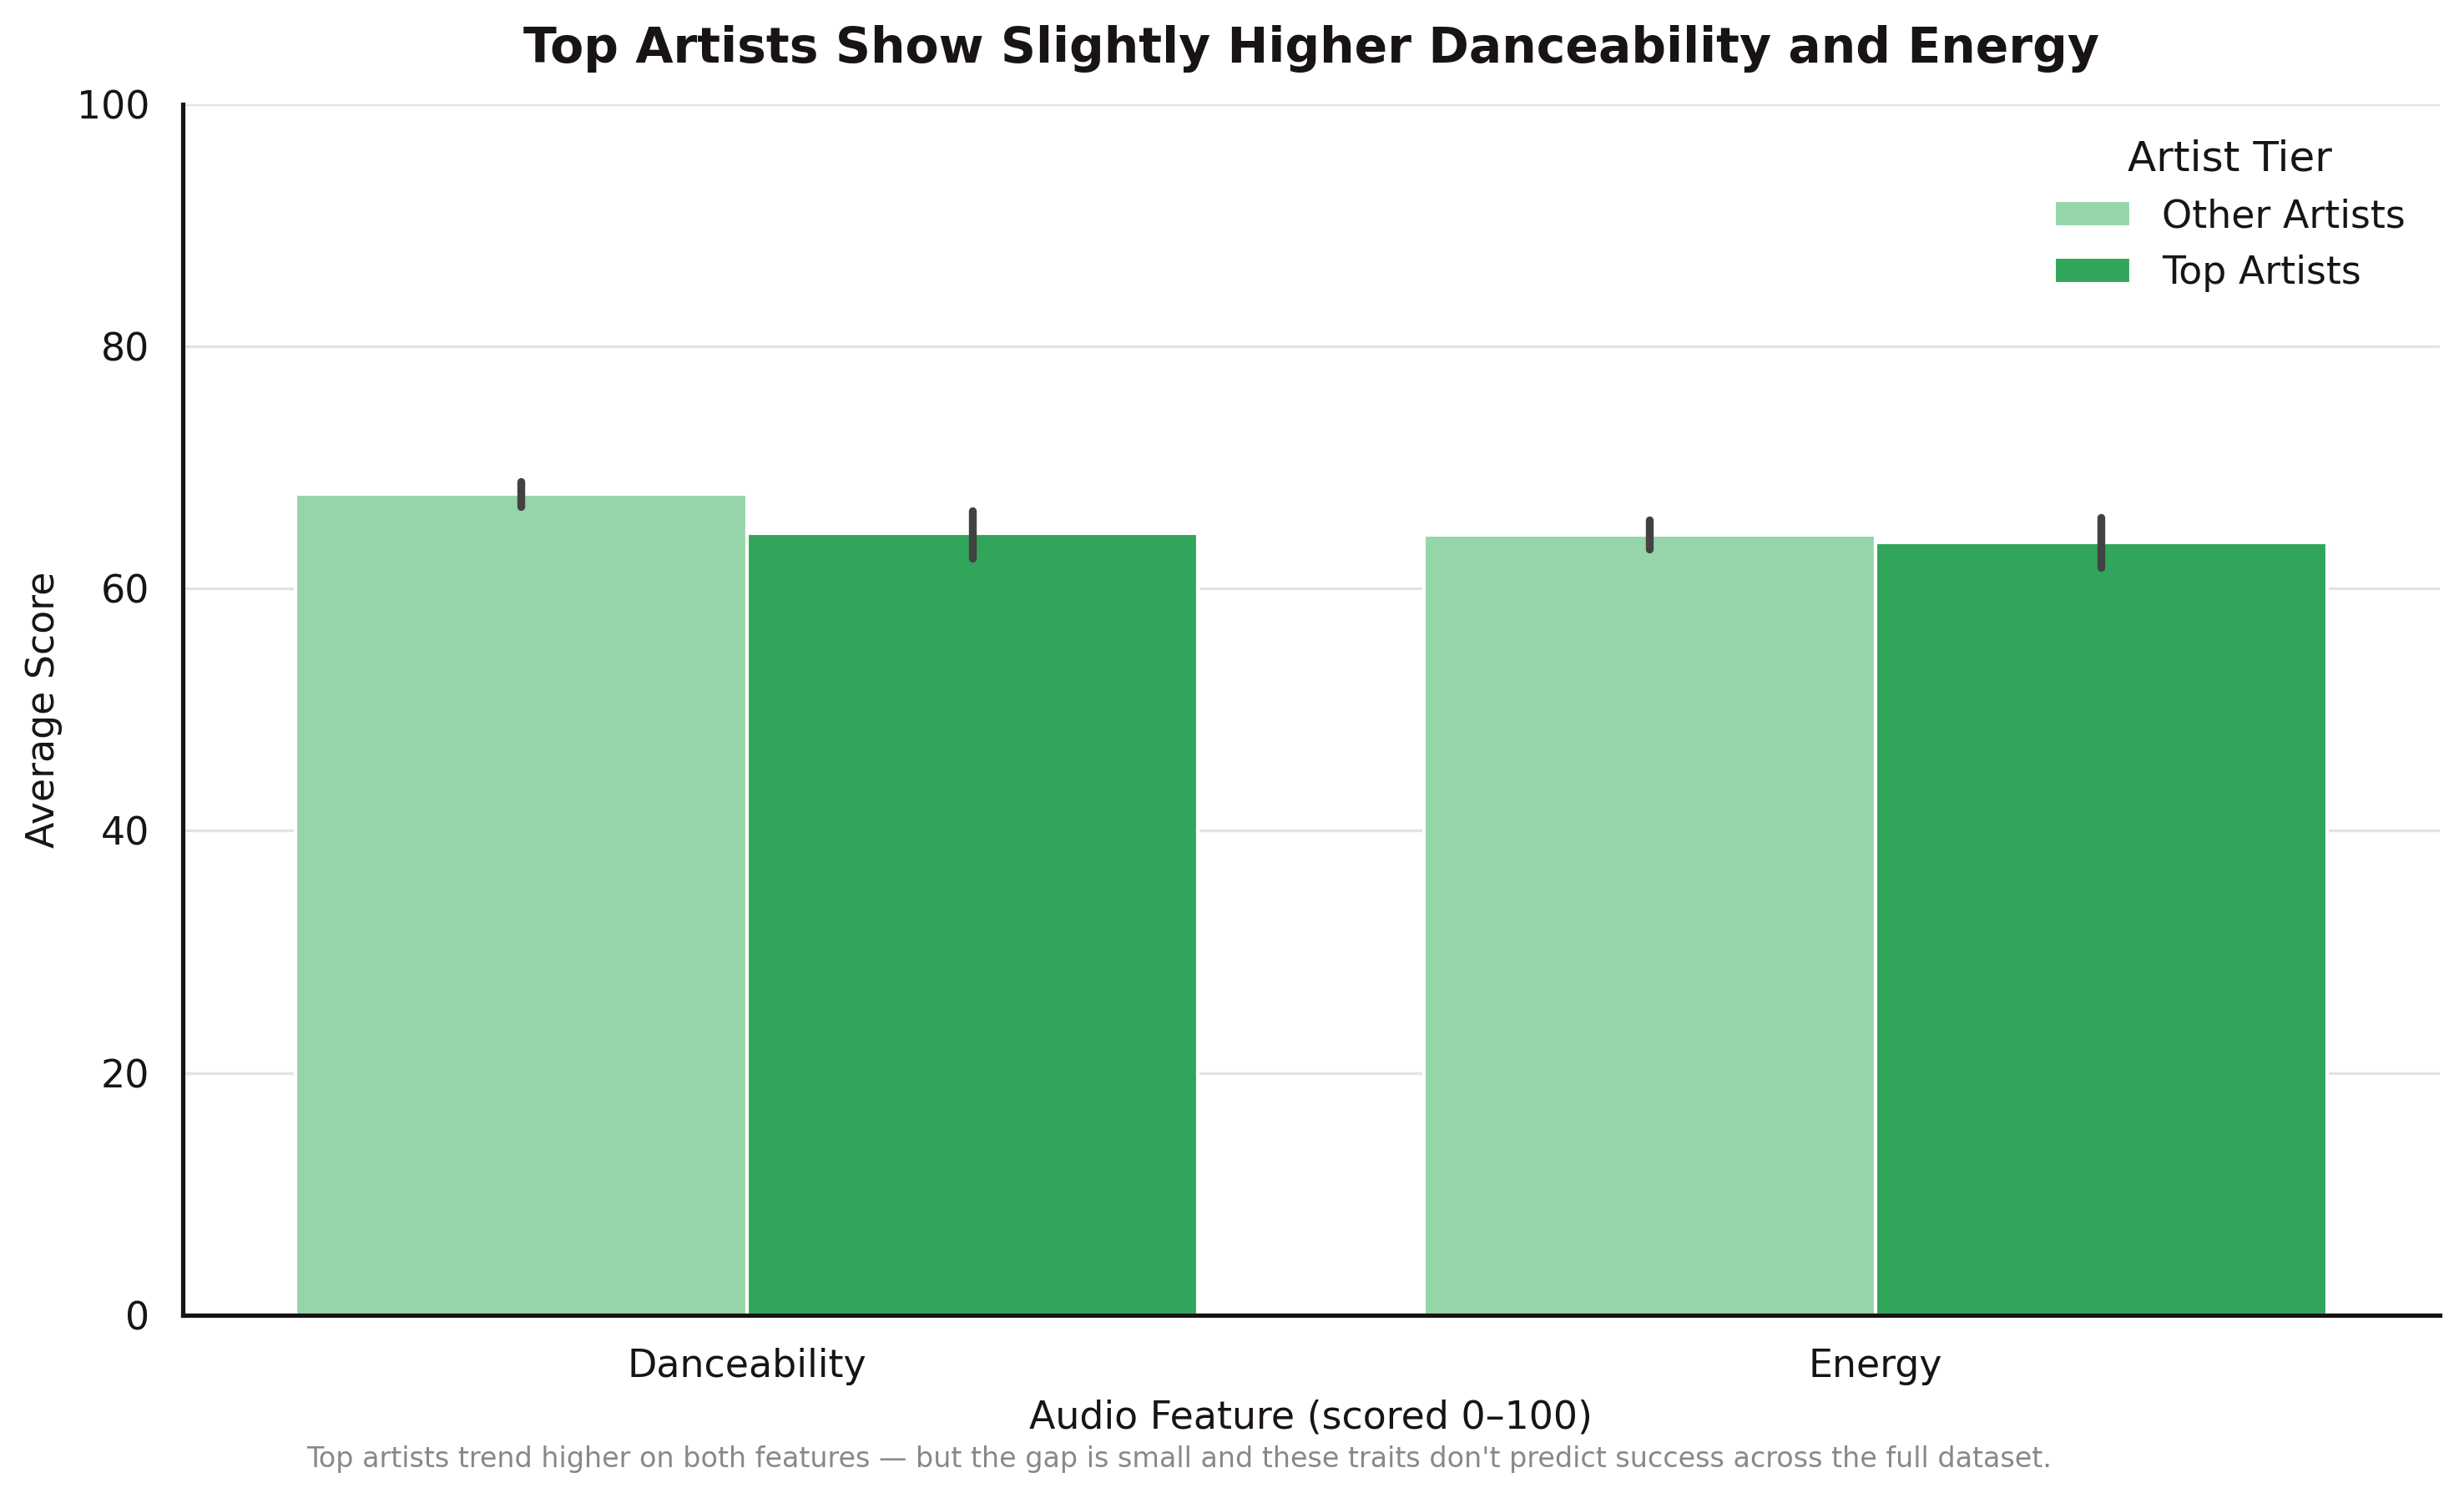

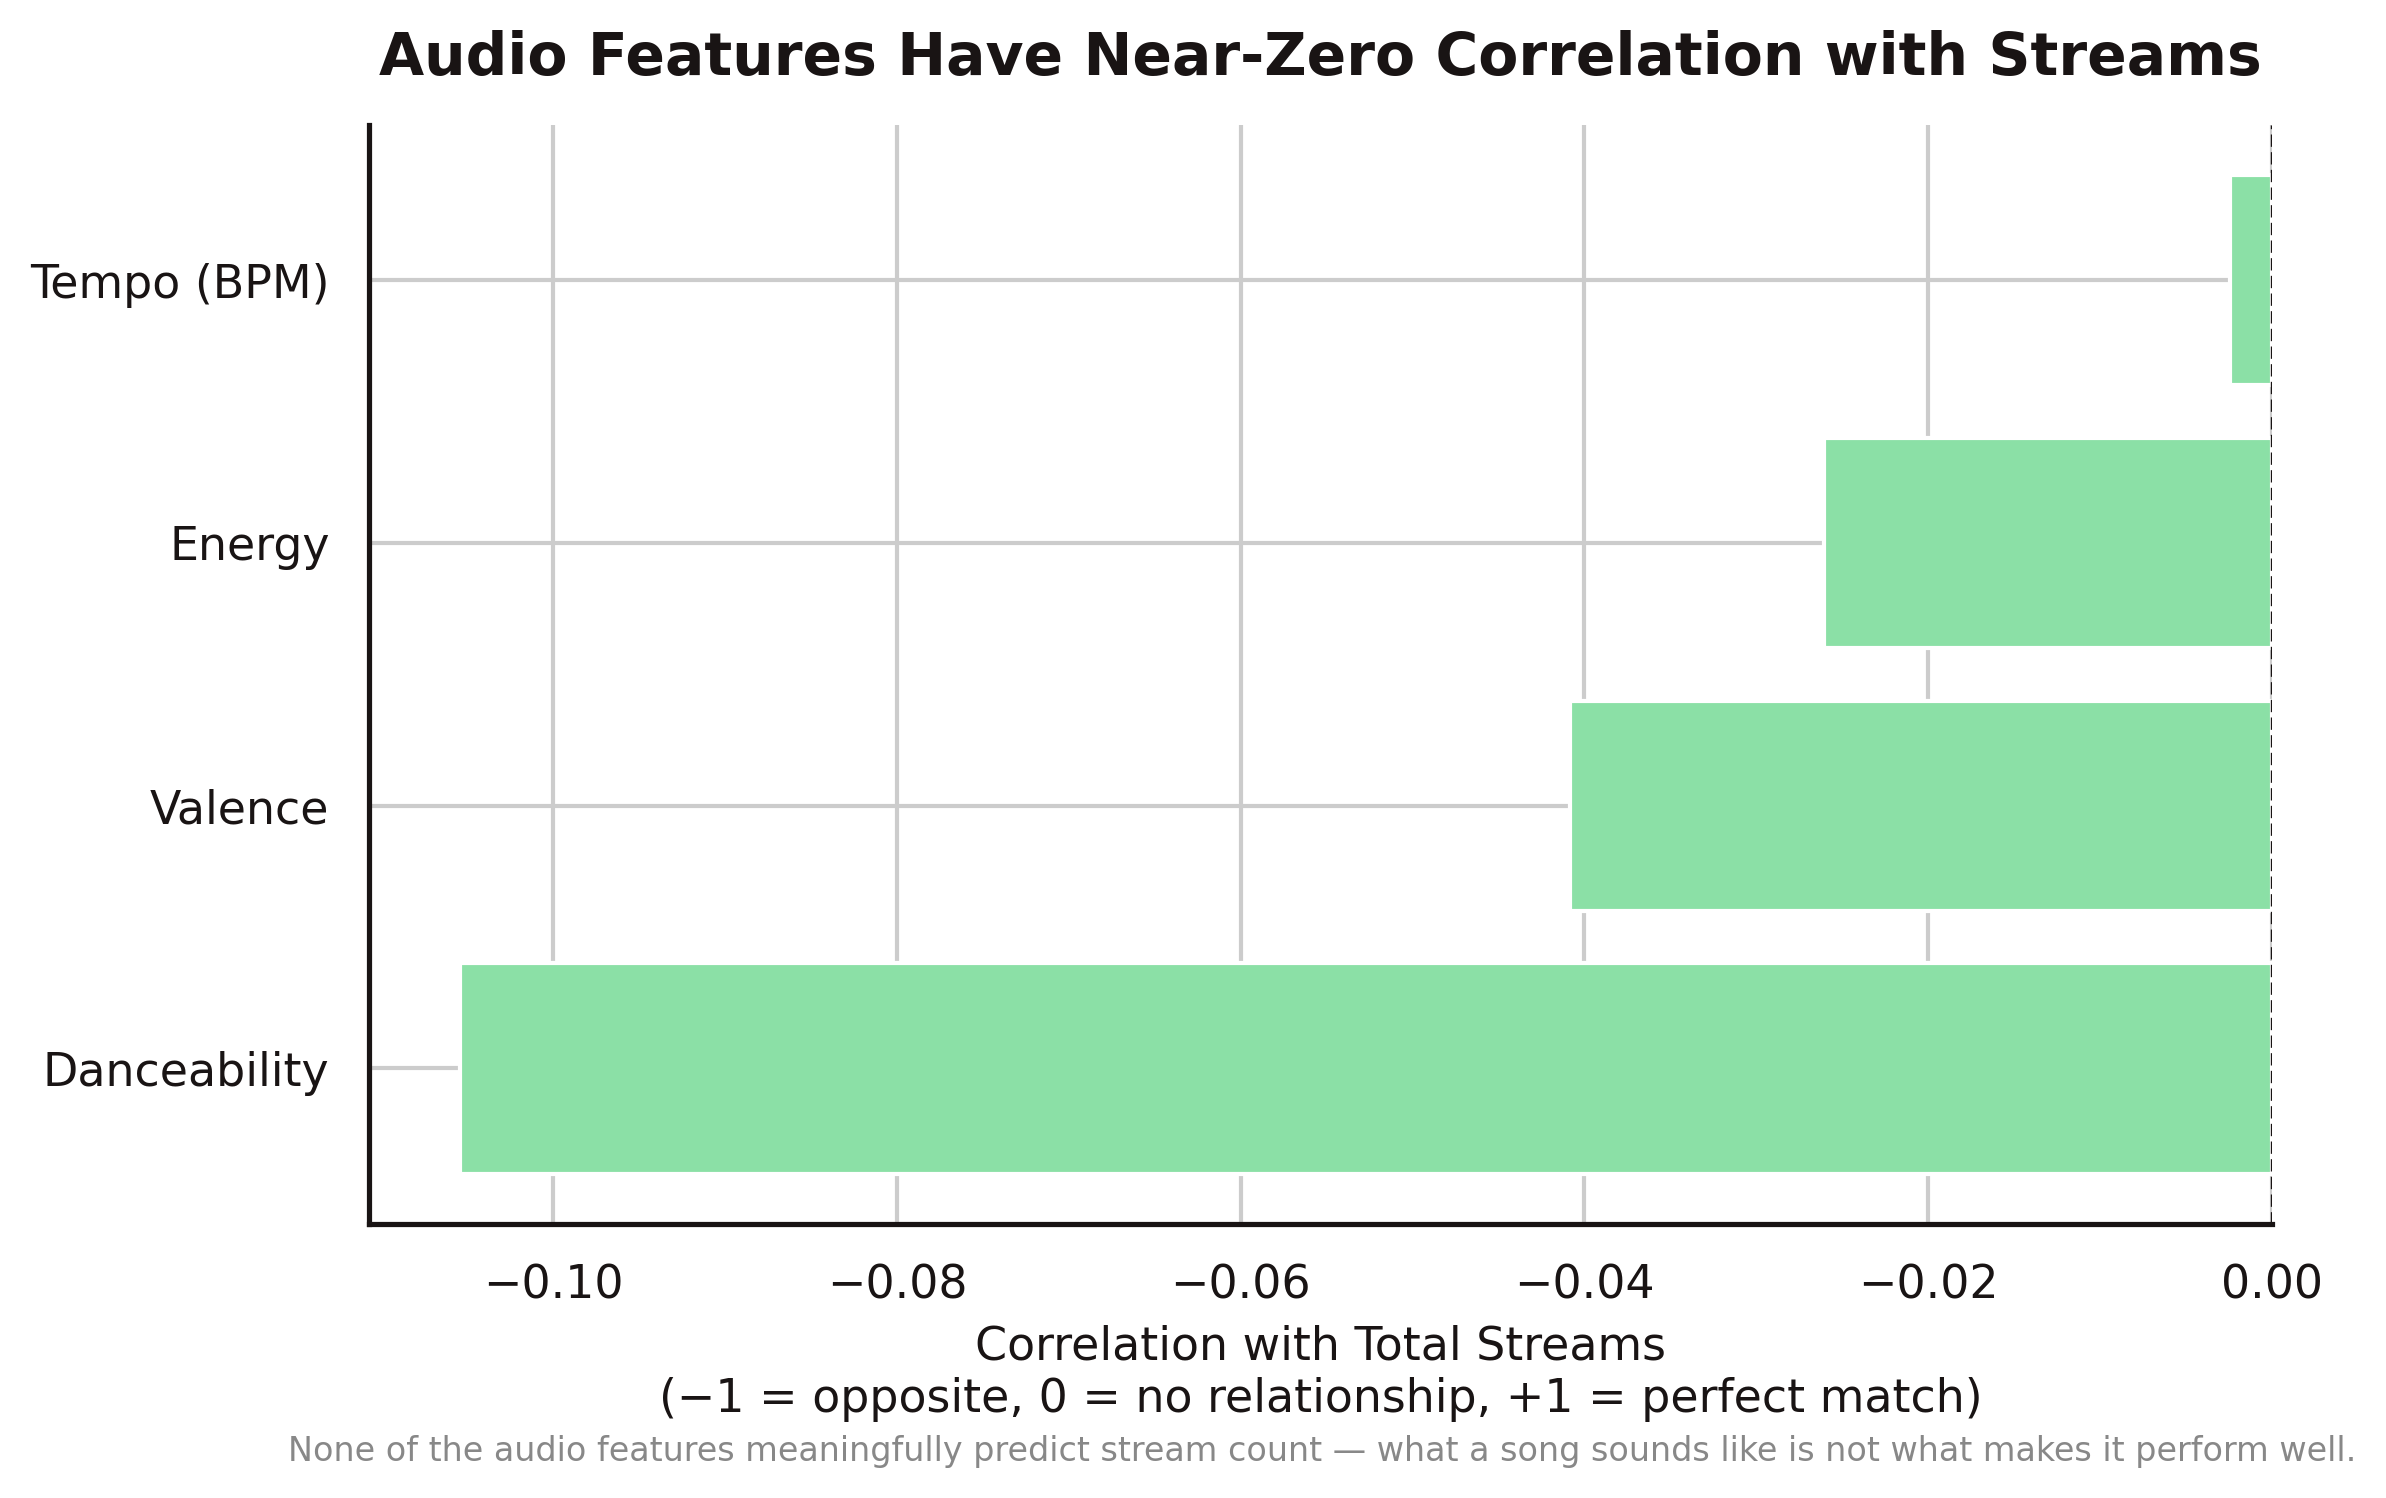


Created zip file: spotify_plots.zip


In [16]:
# ============================================================
# PREDICTING THE NEXT HIT SONG
# Spotify Streaming Analysis | Portfolio Version
# ============================================================

# ------------------------------------------------------------
# 1. Setup
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

import os
import re
import warnings
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from google.colab import files
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind, chi2_contingency

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 2. File paths
# ------------------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/spotify"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

for old_file in [
    "streams_distribution.png",
    "playlist_impact_comparison.png",
    "actual_vs_predicted_streams.png",
    "seasonal_performance_distribution.png",
    "playlist_clustering.png",
    "pca_clusters.png",
    "stream_correlations.png",
    "artist_tier_audio_features.png"
]:
    old_path = os.path.join(PLOTS_DIR, old_file)
    if os.path.exists(old_path):
        os.remove(old_path)

# ------------------------------------------------------------
# 3. Visual style
# ------------------------------------------------------------
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_DARK = "#191414"
SPOTIFY_GRID = "#dddddd"
SPOTIFY_BG = "#ffffff"

GREEN_PALETTE = ["#d9fbe3", "#8be0a6", "#41c96b", "#1DB954"]
CLUSTER_PALETTE = {
    "Low Visibility": "#1DB954",
    "Breaking Through": "#148a3d",
    "Well Known": "#41c96b",
    "Phenomenal": "#8be0a6"
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.edgecolor"] = SPOTIFY_DARK
plt.rcParams["axes.labelcolor"] = SPOTIFY_DARK
plt.rcParams["xtick.color"] = SPOTIFY_DARK
plt.rcParams["ytick.color"] = SPOTIFY_DARK
plt.rcParams["text.color"] = SPOTIFY_DARK
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def apply_chart_style(ax):
    ax.set_facecolor(SPOTIFY_BG)
    ax.grid(True, axis="y", color=SPOTIFY_GRID, linewidth=0.8, alpha=0.8)
    ax.grid(False, axis="x")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(SPOTIFY_DARK)
    ax.spines["bottom"].set_color(SPOTIFY_DARK)

def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.close()

def add_caption(fig, text):
    fig.text(0.13, 0.01, text, fontsize=8, color="#888888", wrap=True)

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------
def detect_csv_file(data_dir: str) -> str:
    csv_files = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in {data_dir}")
    if len(csv_files) == 1:
        return os.path.join(data_dir, csv_files[0])
    preferred_patterns = ["spotify", "songs", "2023", "top"]
    for pattern in preferred_patterns:
        for file_name in csv_files:
            if pattern in file_name.lower():
                return os.path.join(data_dir, file_name)
    return os.path.join(data_dir, csv_files[0])

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        re.sub(r"[^a-z0-9_]+", "_", col.strip().lower()).strip("_")
        for col in df.columns
    ]
    return df

def clean_numeric_series(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

def month_to_season(month: int) -> str:
    if month in [12, 1, 2]:
        return "Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Fall"

# ------------------------------------------------------------
# 5. Load Spotify file
# ------------------------------------------------------------
csv_path = detect_csv_file(DATA_DIR)
print("Using file:", csv_path)

spotify_raw = pd.read_csv(csv_path, encoding="latin1")
spotify_raw = clean_column_names(spotify_raw)

print("\nColumns found:")
print(spotify_raw.columns.tolist())

# ------------------------------------------------------------
# 6. Standardize key columns
# ------------------------------------------------------------
column_map_candidates = {
    "track_name": ["track_name"],
    "artist_name": ["artist_s_name", "artist_name", "artists_name"],
    "streams": ["streams"],
    "released_year": ["released_year"],
    "released_month": ["released_month"],
    "released_day": ["released_day"],
    "in_spotify_playlists": ["in_spotify_playlists"],
    "in_apple_playlists": ["in_apple_playlists"],
    "in_deezer_playlists": ["in_deezer_playlists"],
    "danceability_pct": ["danceability", "danceability_", "danceability_percent", "danceability_pct"],
    "energy_pct": ["energy", "energy_", "energy_percent", "energy_pct"],
    "valence_pct": ["valence", "valence_", "valence_percent", "valence_pct"],
    "bpm": ["bpm"]
}

resolved_cols = {}
for target, candidates in column_map_candidates.items():
    for candidate in candidates:
        if candidate in spotify_raw.columns:
            resolved_cols[target] = candidate
            break

for col in spotify_raw.columns:
    if "danceability" in col and "danceability_pct" not in resolved_cols:
        resolved_cols["danceability_pct"] = col
    if col.startswith("energy") and "in_" not in col and "energy_pct" not in resolved_cols:
        resolved_cols["energy_pct"] = col
    if "valence" in col and "valence_pct" not in resolved_cols:
        resolved_cols["valence_pct"] = col

required = [
    "track_name", "streams", "released_month",
    "in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"
]

missing_required = [col for col in required if col not in resolved_cols]
if missing_required:
    raise ValueError(f"Missing expected columns: {missing_required}")

# ------------------------------------------------------------
# 7. Prepare final dataset
# ------------------------------------------------------------
spotify = pd.DataFrame()
spotify["track_name"] = spotify_raw[resolved_cols["track_name"]]
spotify["streams"] = clean_numeric_series(spotify_raw[resolved_cols["streams"]])
spotify["released_month"] = clean_numeric_series(spotify_raw[resolved_cols["released_month"]])
spotify["in_spotify_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_spotify_playlists"]])
spotify["in_apple_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_apple_playlists"]])
spotify["in_deezer_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_deezer_playlists"]])

if "artist_name" in resolved_cols:
    spotify["artist_name"] = spotify_raw[resolved_cols["artist_name"]].astype(str)
if "released_year" in resolved_cols:
    spotify["released_year"] = clean_numeric_series(spotify_raw[resolved_cols["released_year"]])
if "danceability_pct" in resolved_cols:
    spotify["danceability_pct"] = clean_numeric_series(spotify_raw[resolved_cols["danceability_pct"]])
if "energy_pct" in resolved_cols:
    spotify["energy_pct"] = clean_numeric_series(spotify_raw[resolved_cols["energy_pct"]])
if "valence_pct" in resolved_cols:
    spotify["valence_pct"] = clean_numeric_series(spotify_raw[resolved_cols["valence_pct"]])
if "bpm" in resolved_cols:
    spotify["bpm"] = clean_numeric_series(spotify_raw[resolved_cols["bpm"]])

spotify = spotify.dropna(subset=[
    "streams", "released_month",
    "in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"
]).copy()

spotify = spotify[spotify["streams"] > 0].reset_index(drop=True).copy()

spotify["season"] = spotify["released_month"].astype(int).apply(month_to_season)
spotify["total_playlist_presence"] = (
    spotify["in_spotify_playlists"] +
    spotify["in_apple_playlists"] +
    spotify["in_deezer_playlists"]
)
spotify["log_streams"] = np.log1p(spotify["streams"])

spotify["performance_tier"] = pd.qcut(
    spotify["streams"], q=4,
    labels=["Lower", "Mid-Lower", "Mid-Upper", "Top"]
)

if "artist_name" in spotify.columns:
    artist_streams = spotify.groupby("artist_name")["streams"].sum()
    top_artist_threshold = artist_streams.quantile(0.75)
    top_artists = artist_streams[artist_streams >= top_artist_threshold].index
    spotify["is_top_artist"] = spotify["artist_name"].isin(top_artists)
else:
    spotify["is_top_artist"] = spotify["streams"] >= spotify["streams"].quantile(0.75)

print("\nPrepared dataset shape:", spotify.shape)
print(f"Top artists: {spotify['is_top_artist'].sum()} songs from top-tier artists")
print("\nDescriptive statistics:")
print(spotify[[
    "streams", "in_spotify_playlists",
    "in_apple_playlists", "in_deezer_playlists"
]].describe())

# ------------------------------------------------------------
# 8. Regression model
# ------------------------------------------------------------
model_df = spotify[[
    "log_streams", "in_spotify_playlists",
    "in_apple_playlists", "in_deezer_playlists"
]].dropna().copy()

X = sm.add_constant(model_df[[
    "in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"
]])
y = model_df["log_streams"]
model = sm.OLS(y, X).fit()

print("\n" + "=" * 70)
print("REGRESSION SUMMARY")
print("=" * 70)
print(model.summary())

scaled_df = model_df.copy()
for col in ["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists", "log_streams"]:
    scaled_df[col] = (scaled_df[col] - scaled_df[col].mean()) / scaled_df[col].std()

X_scaled = sm.add_constant(scaled_df[[
    "in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"
]])
y_scaled = scaled_df["log_streams"]
scaled_model = sm.OLS(y_scaled, X_scaled).fit()

coef_summary = pd.DataFrame({
    "platform": ["Spotify", "Apple Music", "Deezer"],
    "coefficient": [
        scaled_model.params["in_spotify_playlists"],
        scaled_model.params["in_apple_playlists"],
        scaled_model.params["in_deezer_playlists"]
    ]
}).sort_values("coefficient", ascending=False)

spotify["predicted_log_streams"] = np.nan
spotify.loc[model_df.index, "predicted_log_streams"] = model.predict(X)
spotify["predicted_streams"] = np.expm1(spotify["predicted_log_streams"])

print("\n" + "=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)
print(f"\nDataset size: {len(spotify):,}")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
print("\nRelative playlist impact (standardized coefficients):")
print(coef_summary.to_string(index=False))

# ------------------------------------------------------------
# 9. Hypothesis testing
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("HYPOTHESIS TESTING")
print("=" * 70)

feature_cols = ["danceability_pct", "energy_pct"]
available_features = [col for col in feature_cols if col in spotify.columns]

if available_features:
    top_songs = spotify[spotify["is_top_artist"] == True]
    non_top_songs = spotify[spotify["is_top_artist"] == False]
    for feature in available_features:
        top_vals = top_songs[feature].dropna()
        non_top_vals = non_top_songs[feature].dropna()
        t_stat, p_val = ttest_ind(top_vals, non_top_vals, equal_var=False)
        print(f"\nT-test: Top Artists vs Non-Top Artists — {feature}")
        print(f"  Top artist mean:     {top_vals.mean():.2f}")
        print(f"  Non-top artist mean: {non_top_vals.mean():.2f}")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {p_val:.6f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
else:
    print("Audio feature columns not found — skipping t-tests")

contingency = pd.crosstab(spotify["season"], spotify["performance_tier"])
chi2_stat, chi2_p_value, chi2_dof, chi2_expected = chi2_contingency(contingency)

print(f"\nChi-square Test: Release Season vs Performance Tier")
print(f"  Chi-square: {chi2_stat:.4f}")
print(f"  Degrees of freedom: {chi2_dof}")
print(f"  P-value: {chi2_p_value:.6f}")
print(f"  Significant: {'Yes' if chi2_p_value < 0.05 else 'No'}")

# ------------------------------------------------------------
# 10. Clustering and PCA
# ------------------------------------------------------------
cluster_df = spotify[[
    "streams", "in_spotify_playlists",
    "in_apple_playlists", "in_deezer_playlists"
]].dropna().copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(scaled_features)

# Label clusters by median streams so names are meaningful
cluster_medians = cluster_df.groupby("cluster")["streams"].median().sort_values()
cluster_label_map = {}
tier_names = ["Low Visibility", "Breaking Through", "Well Known", "Phenomenal"]
for i, (cluster_id, _) in enumerate(cluster_medians.items()):
    cluster_label_map[cluster_id] = tier_names[i]

cluster_df["cluster_label"] = cluster_df["cluster"].map(cluster_label_map)

spotify["cluster"] = np.nan
spotify["cluster_label"] = np.nan
spotify.loc[cluster_df.index, "cluster"] = cluster_df["cluster"]
spotify.loc[cluster_df.index, "cluster_label"] = cluster_df["cluster_label"]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
cluster_df["pca1"] = pca_result[:, 0]
cluster_df["pca2"] = pca_result[:, 1]

print("\n" + "=" * 70)
print("CLUSTERING RESULTS")
print("=" * 70)
print(cluster_df["cluster_label"].value_counts())
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 11. Audio feature correlations
# ------------------------------------------------------------
all_feature_cols = ["danceability_pct", "energy_pct", "valence_pct", "bpm"]
available_all = [col for col in all_feature_cols if col in spotify.columns]

if available_all:
    corr_df = spotify[available_all + ["streams"]].dropna().copy()
    stream_corr = corr_df.corr()["streams"].drop("streams").sort_values()
    print("\n" + "=" * 70)
    print("AUDIO FEATURE CORRELATIONS WITH STREAMS")
    print("=" * 70)
    print(stream_corr)
else:
    stream_corr = None

# ------------------------------------------------------------
# 12. Portfolio-ready charts
# ------------------------------------------------------------

# 12A. Streams distribution
fig, ax = plt.subplots()
sns.histplot(
    spotify["log_streams"], bins=40,
    color=SPOTIFY_GREEN, edgecolor="white", linewidth=0.3, ax=ax
)
ax.set_title("Most Songs Receive Moderate Streaming Attention", pad=12)
ax.set_xlabel("Streaming Performance (scaled for readability)")
ax.set_ylabel("Number of Songs")
add_caption(fig, "Even among Spotify's top songs of 2023, most cluster in a moderate performance range — a small number break far ahead.")
apply_chart_style(ax)
save_plot("streams_distribution.png")

# 12B. Playlist platform impact
fig, ax = plt.subplots()
colors = [SPOTIFY_GREEN if c >= 0 else "#e05c5c" for c in coef_summary["coefficient"]]
sns.barplot(
    data=coef_summary, x="platform", y="coefficient",
    palette=dict(zip(coef_summary["platform"], colors)), ax=ax
)
ax.axhline(0, color=SPOTIFY_DARK, linewidth=0.8, linestyle="--")
ax.set_title("Spotify Playlists Have the Strongest Impact on Streams", pad=12)
ax.set_xlabel("Platform")
ax.set_ylabel("Relative Influence on Streaming Performance")
add_caption(fig, "Standardized regression coefficients — Spotify editorial placement is the single highest-leverage distribution channel. Deezer shows no positive relationship.")
apply_chart_style(ax)
save_plot("playlist_impact_comparison.png")

# 12C. Actual vs predicted
fit_base = spotify.dropna(subset=["predicted_streams"])
fit_sample = fit_base.sample(min(500, len(fit_base)), random_state=42).copy()

jitter_scale = 0.05
fit_sample["streams_jittered"] = fit_sample["streams"] * np.exp(
    np.random.normal(0, jitter_scale, size=len(fit_sample))
)
fit_sample["predicted_jittered"] = fit_sample["predicted_streams"] * np.exp(
    np.random.normal(0, jitter_scale, size=len(fit_sample))
)

fig, ax = plt.subplots()
ax.scatter(
    fit_sample["streams_jittered"],
    fit_sample["predicted_jittered"],
    alpha=0.3, s=20, color=SPOTIFY_GREEN
)

max_val = max(
    fit_sample["streams"].quantile(0.99),
    fit_sample["predicted_streams"].quantile(0.99)
)
min_val = min(
    fit_sample["streams"].quantile(0.01),
    fit_sample["predicted_streams"].quantile(0.01)
)
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color=SPOTIFY_DARK, linewidth=1.5, label="Perfect prediction")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Model Captures Overall Streaming Trends (R²=0.727)", pad=12)
ax.set_xlabel("Actual Streams — how many times the song was played")
ax.set_ylabel("Predicted Streams — what the model estimated")
ax.legend(frameon=False, fontsize=9)
add_caption(fig, "Points near the dashed line = accurate predictions. Songs above the line outperformed what their playlist presence would predict — viral outliers the model doesn't fully capture.")
apply_chart_style(ax)
save_plot("actual_vs_predicted_streams.png")

# 12D. Seasonal performance distribution
season_perf = (
    spotify.groupby(["season", "performance_tier"], observed=False)
    .size().reset_index(name="count")
)

season_order = ["Spring", "Summer", "Fall", "Winter"]
tier_order = ["Lower", "Mid-Lower", "Mid-Upper", "Top"]

season_perf["season"] = pd.Categorical(
    season_perf["season"], categories=season_order, ordered=True
)
season_perf["performance_tier"] = pd.Categorical(
    season_perf["performance_tier"], categories=tier_order, ordered=True
)
season_perf = season_perf.sort_values(["season", "performance_tier"])

season_pivot = season_perf.pivot(
    index="season", columns="performance_tier", values="count"
).fillna(0)
season_pct = season_pivot.div(season_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
bottom = np.zeros(len(season_pct))
for i, col in enumerate(season_pct.columns):
    ax.bar(season_pct.index, season_pct[col], bottom=bottom,
           label=col, color=GREEN_PALETTE[i])
    bottom += season_pct[col].values

ax.set_title("Song Performance Mix Changes Across Release Seasons", pad=12)
ax.set_xlabel("Release Season")
ax.set_ylabel("Share of Songs (%)")
ax.legend(title="Performance Tier", frameon=False)
add_caption(fig, "Winter releases show the highest share of top-tier songs (χ²=27.92, p=.001) — release timing meaningfully affects a track's chance of breaking through.")
apply_chart_style(ax)
save_plot("seasonal_performance_distribution.png")

# 12E. Clustering: playlist presence vs streams
fig, ax = plt.subplots()
sns.scatterplot(
    data=cluster_df, x="in_spotify_playlists", y="streams",
    hue="cluster_label", palette=CLUSTER_PALETTE,
    alpha=0.6, s=35, ax=ax,
    hue_order=["Low Visibility", "Breaking Through", "Well Known", "Phenomenal"]
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Songs Group into Distinct Performance Tiers by Playlist Exposure", pad=12)
ax.set_xlabel("Number of Spotify Playlists the Song Appears In")
ax.set_ylabel("Total Streams")
ax.legend(title="Performance Tier", frameon=False)
add_caption(fig, "K-means clustering (k=4) on playlist presence and stream volume — songs with more playlist placements consistently reach higher stream counts.")
apply_chart_style(ax)
save_plot("playlist_clustering.png")

# 12F. PCA cluster visualization
fig, ax = plt.subplots()
sns.scatterplot(
    data=cluster_df, x="pca1", y="pca2",
    hue="cluster_label", palette=CLUSTER_PALETTE,
    alpha=0.7, s=35, ax=ax,
    hue_order=["Low Visibility", "Breaking Through", "Well Known", "Phenomenal"]
)
ax.set_title("Four Distinct Song Performance Groups Confirmed", pad=12)
ax.set_xlabel("Overall Playlist Exposure (increases right →)")
ax.set_ylabel("Platform Mix — Apple vs Deezer Balance (increases up ↑)")
ax.legend(title="Performance Tier", frameon=False)
add_caption(fig, "PCA reduces 4 variables to 2 dimensions to confirm the clusters are genuinely distinct — not an artifact of the algorithm.")
apply_chart_style(ax)
save_plot("pca_clusters.png")

# 12G. Top vs non-top artist audio features — honest title, fixed y-axis
if available_features:
    feature_compare = spotify[available_features + ["is_top_artist"]].dropna().copy()
    feature_compare["artist_tier"] = feature_compare["is_top_artist"].map(
        {True: "Top Artists", False: "Other Artists"}
    )
    feature_melt = feature_compare.melt(
        id_vars="artist_tier", value_vars=available_features,
        var_name="feature", value_name="score"
    )
    feature_melt["feature"] = feature_melt["feature"].str.replace("_pct", "").str.title()

    fig, ax = plt.subplots()
    sns.barplot(
        data=feature_melt, x="feature", y="score", hue="artist_tier",
        palette={"Top Artists": SPOTIFY_GREEN, "Other Artists": "#8be0a6"},
        ax=ax
    )
    ax.set_title("Top Artists Show Slightly Higher Danceability and Energy", pad=12)
    ax.set_xlabel("Audio Feature (scored 0–100)")
    ax.set_ylabel("Average Score")
    ax.set_ylim(0, 100)
    ax.legend(title="Artist Tier", frameon=False)
    add_caption(fig, "Top artists trend higher on both features — but the gap is small and these traits don't predict success across the full dataset.")
    apply_chart_style(ax)
    save_plot("artist_tier_audio_features.png")

# 12H. Stream correlations — supporting evidence, kept last
if stream_corr is not None:
    corr_df_plot = stream_corr.reset_index()
    corr_df_plot.columns = ["feature", "correlation"]
    corr_df_plot["feature"] = (
        corr_df_plot["feature"]
        .str.replace("_pct", "")
        .str.replace("_", " ")
        .str.title()
        .str.replace("Bpm", "Tempo (BPM)")
    )
    corr_df_plot["color"] = corr_df_plot["correlation"].apply(
        lambda x: SPOTIFY_GREEN if x >= 0 else "#8be0a6"
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(corr_df_plot["feature"], corr_df_plot["correlation"],
            color=corr_df_plot["color"])
    ax.axvline(0, color=SPOTIFY_DARK, linewidth=0.8, linestyle="--")
    ax.set_title("Audio Features Have Near-Zero Correlation with Streams", pad=12)
    ax.set_xlabel("Correlation with Total Streams\n(−1 = opposite, 0 = no relationship, +1 = perfect match)")
    ax.set_ylabel("")
    add_caption(fig, "None of the audio features meaningfully predict stream count — what a song sounds like is not what makes it perform well.")
    ax.set_facecolor(SPOTIFY_BG)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(SPOTIFY_DARK)
    ax.spines["bottom"].set_color(SPOTIFY_DARK)
    save_plot("stream_correlations.png")

print("\nSaved plots:")
print(sorted(os.listdir(PLOTS_DIR)))

# ------------------------------------------------------------
# 13. Preview all charts
# ------------------------------------------------------------
for file_name in [
    "streams_distribution.png",
    "playlist_impact_comparison.png",
    "actual_vs_predicted_streams.png",
    "seasonal_performance_distribution.png",
    "playlist_clustering.png",
    "pca_clusters.png",
    "artist_tier_audio_features.png",
    "stream_correlations.png"
]:
    full_path = os.path.join(PLOTS_DIR, file_name)
    if os.path.exists(full_path):
        display(Image(filename=full_path))

# ------------------------------------------------------------
# 14. Optional: zip plots for download
# ------------------------------------------------------------
shutil.make_archive("spotify_plots", "zip", PLOTS_DIR)
print("\nCreated zip file: spotify_plots.zip")
# files.download("spotify_plots.zip")